In [1]:
import dill
with open("empirical_results/nats_sss_known_cost_metrics_per_acq_updated.pkl", "rb") as f:
    metrics_per_acq = dill.load(f)

In [2]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'

In [3]:
best_acc_per_dataset = {
    'cifar10-valid': 90.5,
    'cifar100': 71.34,
    'ImageNet16-120': 47.4,
}

In [4]:
# import torch
# import numpy as np
# import os

# # Define the path to the precomputed test accuracies
# data_root = 'NATS_data/sss_data'

# dataset_names = ['cifar10-valid', 'cifar100', 'ImageNet16-120']
# acquisition_functions = ['LogEIPC', 'PBGI(1e-4)', 'PBGI(1e-5)', 'PBGI(1e-6)', 'LCB', 'TS']

# # Loop over each dataset and acquisition function
# for d in dataset_names:
#     # Load test accuracy tensor for this dataset once
#     test_acc_tensor = torch.load(os.path.join(data_root, f'nats_{d}_test_acc.pt'))

#     for a in acquisition_functions:
#         # Access current best IDs
#         best_ids = np.array(metrics_per_acq[d][a]["current best id"])
#         n_seeds, n_iterations = best_ids.shape

#         # Prepare array to store test errors
#         test_error_mat = np.empty((n_seeds, n_iterations))

#         # Use best config IDs to query test error
#         for s in range(n_seeds):
#             for i in range(n_iterations):
#                 config_id = best_ids[s, i]
#                 test_error_mat[s, i] = 100.0 - test_acc_tensor[config_id].item()

#         # Store in unified structure
#         metrics_per_acq[d][a]["final test error"] = test_error_mat

# # Save to pkl
# import pickle
# output_path = "empirical_results/nats_sss_known_cost_metrics_per_acq_updated.pkl"
# with open(output_path, "wb") as f:
#     pickle.dump(metrics_per_acq, f)

In [4]:
import numpy as np

# === User‐provided data and helper functions (assumed to exist) ===
# metrics_per_acq[d][acq_key]["estimated cumulative cost"]
# test_metrics_per_acq[d][acq_key]["final test error"]
# bench.query_best_final(dataset, "final_test_accuracy", "final_test_accuracy", 0)

# === Config ===
dataset_names = ['cifar10-valid', 'cifar100', 'ImageNet16-120']
lambdas       = [1e-4, 1e-5, 1e-6]
acq_order     = ['LogEIPC', 'PBGI', 'LCB', 'TS']
init          = 0


cost_limit_per_dataset = {
    "cifar10-valid":    240000,
    "cifar100":         400000,
    "ImageNet16-120":   400000
}

# === Color and marker settings ===
color_dict = {
    'LogEIPC':      'tab:blue',
    'LogEIPC-med':  'tab:blue',
    'PBGI(1e-4)':  'tab:orange',
    'PBGI(1e-5)':  'tab:orange',
    'PBGI(1e-6)':  'tab:orange',
    'LCB':         'tab:purple',
    'UCB-LCB':     'tab:purple',
    'SRGap-med':   'tab:pink',
    'TS':          'tab:brown',
    'PRB':         'tab:brown',
    'GSS':         'tab:olive',
    'Convergence': 'tab:gray',
    'Immediate':   'tab:cyan',
    'Hindsight':   'tab:red'
}

# === Build stopping_rules for each λ ===
stopping_rules = []
for lam in lambdas:
    lam_str   = f"1e-{int(round(-np.log10(lam)))}"  # “1e-4”, “1e-5”, “1e-6”
    fixed_acq = f"PBGI({lam_str})"

    templates = [
        {
            'stp_key':      'PBGI',
            'is_hindsight': False,
            'condition_fn': (lambda i, seed, d, lam=lam, fa=fixed_acq: (
                i >= init and
                metrics_per_acq[d][fa][f"{fa} acq"][seed][i] >=
                metrics_per_acq[d][fa]["current best observed"][seed][i - 1]
            ))
        },
        # {
        #     'stp_key':      'LogEIPC',
        #     'is_hindsight': False,
        #     'condition_fn': (lambda i, seed, d, lam=lam, fa=fixed_acq: (
        #         i >= init and
        #         metrics_per_acq[d][fa]["LogEIPC acq"][seed][i] <= np.log(lam)
        #     ))
        # },
        {
            'stp_key':      'LogEIPC-med',
            'is_hindsight': False,
            'condition_fn': (lambda i, seed, d, fa=fixed_acq: (
                i >= init and
                metrics_per_acq[d][fa]["LogEIPC acq"][seed][i] <= (
                    np.log(0.01) +
                    np.nanmedian(metrics_per_acq[d][fa]["LogEIPC acq"][seed][1:21])
                )
            ))
        },
        {
            'stp_key':      'SRGap-med',
            'is_hindsight': False,
            'condition_fn': (lambda i, seed, d, fa=fixed_acq: (
                i >= init and
                metrics_per_acq[d][fa]["exp min regret gap"][seed][i] <=
                0.01 * np.nanmedian(
                    metrics_per_acq[d][fa]["exp min regret gap"][seed][1:21]
                )
            ))
        },
        {
            'stp_key':      'UCB-LCB',
            'is_hindsight': False,
            'condition_fn': (lambda i, seed, d, fa=fixed_acq: (
                i >= init and
                metrics_per_acq[d][fa]["regret upper bound"][seed][i] <= 0.01
            ))
        },
        {
            'stp_key':      'GSS',
            'is_hindsight': False,
            'condition_fn': (lambda i, seed, d, fa=fixed_acq: (
                i >= init and (
                    (np.nanpercentile(
                        metrics_per_acq[d][fa]["current best observed"][seed][:i+1], 75
                     ) -
                     np.nanpercentile(
                        metrics_per_acq[d][fa]["current best observed"][seed][:i+1], 25
                     )) == 0
                ) or (
                    ((metrics_per_acq[d][fa]["current best observed"][seed][i - 5] -
                      metrics_per_acq[d][fa]["current best observed"][seed][i]) /
                     (np.nanpercentile(
                        metrics_per_acq[d][fa]["current best observed"][seed][:i+1], 75
                     ) -
                      np.nanpercentile(
                        metrics_per_acq[d][fa]["current best observed"][seed][:i+1], 25
                     ))
                    ) <= 0.01
                )
            ))
        },
        {
            'stp_key':      'Convergence',
            'is_hindsight': False,
            'condition_fn': (lambda i, seed, d, fa=fixed_acq: (
                i >= init and
                metrics_per_acq[d][fa]["current best observed"][seed][i] ==
                metrics_per_acq[d][fa]["current best observed"][seed][i - 5]
            ))
        },
        {
            'stp_key':      'PRB',
            'is_hindsight': False,
            'condition_fn': (lambda i, seed, d, fa=fixed_acq: (
                i >= init and
                metrics_per_acq[d][fa]["PRB"][seed][i] >= 0.95
            ))
        },
        {
            'stp_key':      'Immediate',
            'is_hindsight': False,
            'condition_fn': (lambda i, seed, d, fa=fixed_acq: (
                i >= 0
            ))
        },
        {
            'stp_key':      'Hindsight',
            'is_hindsight': True,
            'condition_fn': None
        }
    ]

    for temp in templates:
        rule = {
            'acq_key':      fixed_acq,
            'stp_key':      temp['stp_key'],
            'is_hindsight': temp['is_hindsight'],
            'marker':       'x' if temp['stp_key'] == 'Hindsight' else 's',
            'color':        color_dict.get(temp['stp_key'], color_dict[fixed_acq]),
            'label':        'PBGI/LogEIPC' if temp['stp_key'] == 'PBGI' else temp['stp_key']
        }
        if temp['condition_fn'] is not None:
            rule['condition_fn'] = temp['condition_fn']
        stopping_rules.append(rule)

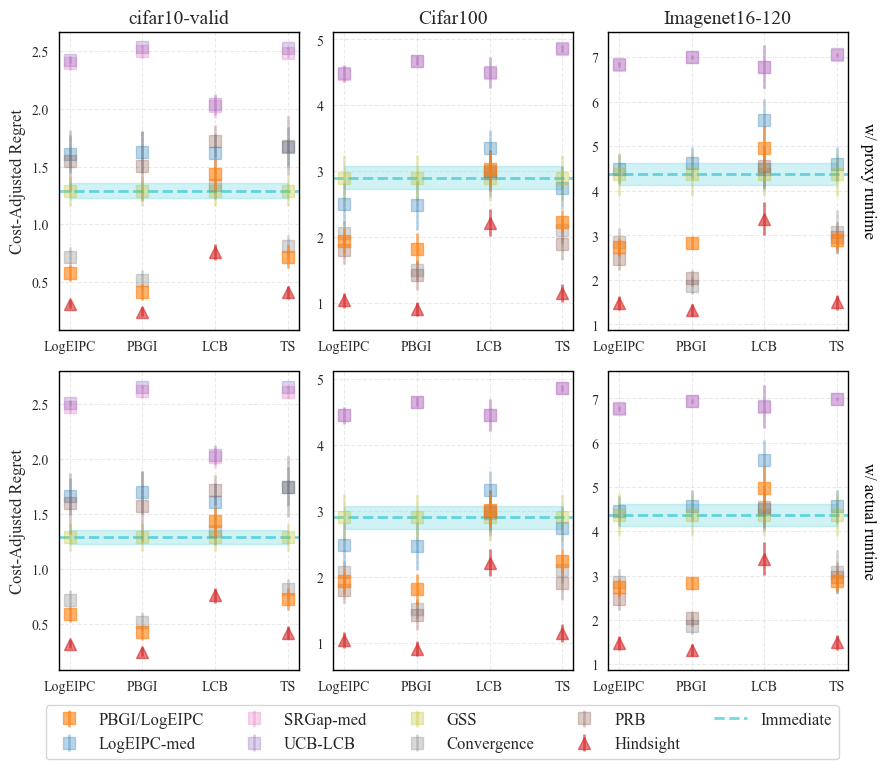

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from math import ceil

# --- Plot style ---
sns.set_style('whitegrid', {
    'grid.linestyle': '--',
    'grid.alpha': 0.4
})

plt.style.use('seaborn-v0_8-bright')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    # 'xtick.rotation': 45,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.autolayout': False,  # we’ll call tight_layout() explicitly
})


def style_spines(ax, color='black', linewidth=1):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(color)
        spine.set_linewidth(linewidth)

# --- Config ---
dataset_names = ['cifar10-valid', 'cifar100', 'ImageNet16-120']
lam = 1e-5
lam_str = '1e-5'
acq_order = ['LogEIPC', 'PBGI', 'LCB', 'TS']
init = 0
n_rows, n_cols = 2, len(dataset_names)
cost_keys = ["estimated cumulative cost", "cumulative cost"]
runtime_labels = ["w/ proxy runtime", "w/ actual runtime"]

# --- Create figure ---
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 4 * n_rows), sharey=False)

for row in range(n_rows):
    cost_key = cost_keys[row]
    runtime_label = runtime_labels[row]

    for col, d in enumerate(dataset_names):
        ax = axes[row][col] if n_rows > 1 else axes[col]
        best_acc = best_acc_per_dataset[d]
        best_error = 100. - best_acc

        # Collect Immediate values across all acquisition functions
        immediate_vals = []
        for j, acq in enumerate(acq_order):
            fixed_acq = f"PBGI({lam_str})" if acq == 'PBGI' else acq
            
            # Find Immediate rule for this acquisition function
            immediate_rule = None
            for rule in stopping_rules:
                if rule['acq_key'] == f"PBGI({lam_str})" and rule['stp_key'] == 'Immediate':
                    immediate_rule = rule
                    break
            
            if immediate_rule:
                stop_vals = []
                num_seeds = len(metrics_per_acq[d][fixed_acq][cost_key])
                for seed in range(num_seeds):
                    errs = metrics_per_acq[d][fixed_acq]["final test error"][seed]
                    costs = metrics_per_acq[d][fixed_acq][cost_key][seed]
                    # Immediate stops at iteration 0
                    stop_idx = 0
                    stop_vals.append((errs[stop_idx] - best_error) + lam * costs[stop_idx])
                immediate_vals.extend(stop_vals)

        for j, acq in enumerate(acq_order):
            fixed_acq = f"PBGI({lam_str})" if acq == 'PBGI' else acq

            for rule in stopping_rules:
                if rule['acq_key'] != f"PBGI({lam_str})":
                    continue
                
                # Skip Immediate rule here - we'll plot it separately
                if rule['stp_key'] == 'Immediate':
                    continue

                stop_vals = []
                for seed in range(len(metrics_per_acq[d][fixed_acq][cost_key])):
                    errs = metrics_per_acq[d][fixed_acq]["final test error"][seed]
                    costs = metrics_per_acq[d][fixed_acq][cost_key][seed]
                    if rule['is_hindsight']:
                        regs = np.array(errs) - best_error + lam * np.array(costs)
                        idx = np.argmin(regs)
                    else:
                        idx = next((k for k in range(init, len(errs)) if rule['condition_fn'](k, seed, d)), len(errs) - 1)
                    stop_vals.append((errs[idx] - best_error) + lam * costs[idx])

                mean_val = np.mean(stop_vals)
                err_val = np.std(stop_vals) / np.sqrt(len(stop_vals))

                alpha = 0.6 if (rule['stp_key'] == 'PBGI' or rule['is_hindsight']) else 0.3
                zorder = 3 if rule['stp_key'] == 'PBGI' else 2
                marker = "^" if rule['is_hindsight'] else rule['marker']
                ax.errorbar(j, mean_val, yerr=2 * err_val,
                            fmt=marker,
                            markersize=8,
                            linewidth=2,
                            color=rule['color'],
                            capsize=0,
                            alpha=alpha,
                            zorder=zorder,
                            label=rule['label'])
        
        # Plot Immediate as horizontal line with shaded error bars
        if immediate_vals:
            immediate_mean = np.mean(immediate_vals)
            immediate_err = np.std(immediate_vals) / np.sqrt(len(immediate_vals))
            
            # Draw horizontal line across all acquisition functions
            ax.axhline(y=immediate_mean, xmin=0, xmax=1, 
                      color='tab:cyan', linestyle='--', linewidth=2, alpha=0.6, zorder=1)
            
            # Add shaded error region
            ax.fill_between([0, len(acq_order)-1], 
                           [immediate_mean - 2*immediate_err, immediate_mean - 2*immediate_err],
                           [immediate_mean + 2*immediate_err, immediate_mean + 2*immediate_err],
                           color='tab:cyan', alpha=0.2, zorder=0)
            
            # Add label only once
            if row == 0 and col == 0:  # Only add label for the first subplot
                ax.plot([], [], color='tab:cyan', linestyle='--', linewidth=2, 
                       alpha=0.6, label='Immediate')

        ax.set_xticks(range(len(acq_order)))
        ax.set_xticklabels(acq_order)
        ax.grid(True, linestyle='--', alpha=0.4)
        style_spines(ax)

        if row == 0:
            ax.set_title(d if d == "cifar10-valid" else d.capitalize())
        if col == 0:
            ax.set_ylabel("Cost-Adjusted Regret")
        if col == n_cols - 1:
            ax.text(1.05, 0.5, runtime_label,
                    transform=ax.transAxes,
                    rotation=-90,
                    va='center',
                    ha='left',
                    fontsize=12,
                    color='black')

# --- Shared legend ---
handles, labels = axes[0][0].get_legend_handles_labels()
legend_hls = dict(zip(labels, handles))

# Move Immediate to the end if it exists
if 'Immediate' in legend_hls:
    immediate_handle = legend_hls.pop('Immediate')
    legend_hls['Immediate'] = immediate_handle

fig.legend(legend_hls.values(), legend_hls.keys(),
           loc='lower center',
           bbox_to_anchor=(0.5, -0.02),
           ncol=ceil(len(legend_hls) / 2),
           fontsize=12)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig('../plots/BarPlot_NATS_cost_mismatch.pdf', bbox_inches='tight')
plt.show()

[cifar10-valid] Acquisition: LogEIPC, Rule: PBGI/LogEIPC, Non-stopping seeds: 0 / 50
[cifar10-valid] Acquisition: LogEIPC, Rule: LogEIPC-med, Non-stopping seeds: 32 / 50
[cifar10-valid] Acquisition: LogEIPC, Rule: SRGap-med, Non-stopping seeds: 50 / 50
[cifar10-valid] Acquisition: LogEIPC, Rule: UCB-LCB, Non-stopping seeds: 50 / 50
[cifar10-valid] Acquisition: LogEIPC, Rule: GSS, Non-stopping seeds: 0 / 50
[cifar10-valid] Acquisition: LogEIPC, Rule: Convergence, Non-stopping seeds: 0 / 50
[cifar10-valid] Acquisition: LogEIPC, Rule: PRB, Non-stopping seeds: 26 / 50
[cifar10-valid] Acquisition: LogEIPC, Rule: Hindsight, Non-stopping seeds: 0 / 50
[cifar10-valid] Acquisition: PBGI, Rule: PBGI/LogEIPC, Non-stopping seeds: 0 / 50
[cifar10-valid] Acquisition: PBGI, Rule: LogEIPC-med, Non-stopping seeds: 32 / 50
[cifar10-valid] Acquisition: PBGI, Rule: SRGap-med, Non-stopping seeds: 50 / 50
[cifar10-valid] Acquisition: PBGI, Rule: UCB-LCB, Non-stopping seeds: 50 / 50
[cifar10-valid] Acquisiti

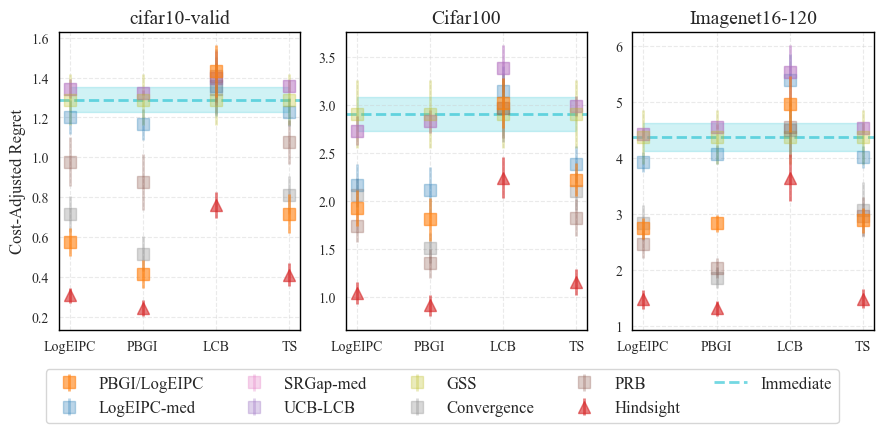

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from math import ceil

# Set style
sns.set_style('whitegrid', {
    'grid.linestyle': '--',
    'grid.alpha': 0.4
})

plt.style.use('seaborn-v0_8-bright')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    # 'xtick.rotation': 45,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.autolayout': False,  # we’ll call tight_layout() explicitly
})


def style_spines(ax, color='black', linewidth=1):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(color)
        spine.set_linewidth(linewidth)

# Config
dataset_names = ['cifar10-valid', 'cifar100', 'ImageNet16-120']
lam = 1e-5
lam_str = '1e-5'
acq_order = ['LogEIPC', 'PBGI', 'LCB', 'TS']
init = 0
n_cols = len(acq_order)

# Set up plot
fig, axes = plt.subplots(1, len(dataset_names), figsize=(3 * len(dataset_names), 4 * 1), sharey=False)

for col, d in enumerate(dataset_names):
    ax = axes[col]
    best_acc = best_acc_per_dataset[d]
    best_error = 100. - best_acc

    # Collect Immediate values across all acquisition functions
    immediate_vals = []
    for j, acq in enumerate(acq_order):
        fixed_acq = f"PBGI({lam_str})" if acq == 'PBGI' else acq
        
        # Find Immediate rule for this acquisition function
        immediate_rule = None
        for rule in stopping_rules:
            if rule['acq_key'] == f"PBGI({lam_str})" and rule['stp_key'] == 'Immediate':
                immediate_rule = rule
                break
        
        if immediate_rule:
            stop_vals = []
            num_seeds = len(metrics_per_acq[d][fixed_acq]["estimated cumulative cost"])
            for seed in range(num_seeds):
                errs = metrics_per_acq[d][fixed_acq]["final test error"][seed][:201]
                costs = metrics_per_acq[d][fixed_acq]["estimated cumulative cost"][seed][:201]
                # Immediate stops at iteration 0
                stop_idx = 0
                stop_vals.append((errs[stop_idx] - best_error) + lam * costs[stop_idx])
            immediate_vals.extend(stop_vals)

    for j, acq in enumerate(acq_order):
        fixed_acq = f"PBGI({lam_str})" if acq == 'PBGI' else acq

        for rule in stopping_rules:
            if rule['acq_key'] != f"PBGI({lam_str})":
                continue
            
            # Skip Immediate rule here - we'll plot it separately
            if rule['stp_key'] == 'Immediate':
                continue

            stop_vals = []
            stop_iters = []
            non_stopping_count = 0  # <-- Track non-stopping seeds
            num_seeds = len(metrics_per_acq[d][fixed_acq]["estimated cumulative cost"])
            for seed in range(num_seeds):
                errs = metrics_per_acq[d][fixed_acq]["final test error"][seed][:201]
                costs = metrics_per_acq[d][fixed_acq]["estimated cumulative cost"][seed][:201]
                if rule['is_hindsight']:
                    regs = np.array(errs) - best_error + lam * np.array(costs)
                    idx = np.argmin(regs)
                else:
                    idx = next((k for k in range(init, len(errs)) if rule['condition_fn'](k, seed, d)), len(errs) - 1)
                    if idx == len(errs) - 1:
                        non_stopping_count += 1  # <-- Count seeds that never stopped early
                stop_vals.append((errs[idx] - best_error) + lam * costs[idx])

            mean_val = np.mean(stop_vals)
            err_val = np.std(stop_vals) / np.sqrt(len(stop_vals))

            alpha = 0.6 if (rule['stp_key'] == 'PBGI' or rule['is_hindsight']) else 0.3
            zorder = 3 if rule['stp_key'] == 'PBGI' else 2
            marker = "^" if rule['is_hindsight'] else 's' 
            ax.errorbar(j, mean_val, yerr=2 * err_val,
                        fmt=marker,
                        markersize=8,
                        linewidth=2,
                        color=rule['color'],
                        capsize=0,
                        alpha=alpha,
                        zorder=zorder,
                        label=rule['label'])
            
            # --- Output non-stopping stats ---
            print(f"[{d}] Acquisition: {acq}, Rule: {rule['label']}, Non-stopping seeds: {non_stopping_count} / {num_seeds}")
    
    # Plot Immediate as horizontal line with shaded error bars
    if immediate_vals:
        immediate_mean = np.mean(immediate_vals)
        immediate_err = np.std(immediate_vals) / np.sqrt(len(immediate_vals))
        
        # Draw horizontal line across all acquisition functions
        ax.axhline(y=immediate_mean, xmin=0, xmax=1, 
                  color='tab:cyan', linestyle='--', linewidth=2, alpha=0.6, zorder=1)
        
        # Add shaded error region
        ax.fill_between([0, len(acq_order)-1], 
                       [immediate_mean - 2*immediate_err, immediate_mean - 2*immediate_err],
                       [immediate_mean + 2*immediate_err, immediate_mean + 2*immediate_err],
                       color='tab:cyan', alpha=0.2, zorder=0)
        
        # Add label only once
        if col == 0:  # Only add label for the first subplot
            ax.plot([], [], color='tab:cyan', linestyle='--', linewidth=2, 
                   alpha=0.6, label='Immediate')

    ax.set_xticks(range(n_cols))
    ax.set_xticklabels(acq_order)
    if (d == "cifar10-valid"):
        ax.set_title(d)
    else:
        ax.set_title(d.capitalize())
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_ylabel("Cost-Adjusted Regret" if col == 0 else "")
    style_spines(ax)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
legend_hls = dict(zip(labels, handles))

# Move Immediate to the end if it exists
if 'Immediate' in legend_hls:
    immediate_handle = legend_hls.pop('Immediate')
    legend_hls['Immediate'] = immediate_handle

fig.legend(legend_hls.values(), legend_hls.keys(),
           loc='lower center',
           bbox_to_anchor=(0.5, -0.15),
           ncol=ceil(len(legend_hls) / 2),
           fontsize=12)

# fig.suptitle(f"Cost-Adjusted Regret (λ = {str(lam)})", fontsize=20)
plt.tight_layout(rect=[0, 0.0, 1, 0.95])
plt.savefig(f'../plots/BarPlot_NATS.pdf', bbox_inches='tight')
plt.show()

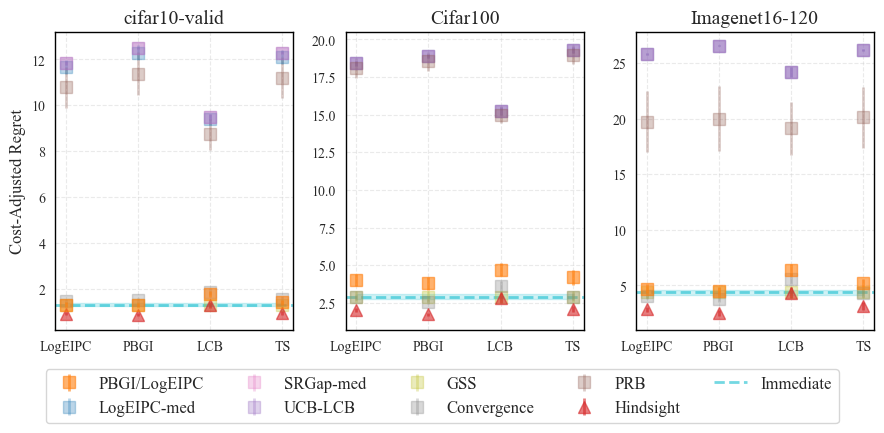

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from math import ceil

# Set style
sns.set_style('whitegrid', {
    'grid.linestyle': '--',
    'grid.alpha': 0.4
})

plt.style.use('seaborn-v0_8-bright')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    # 'xtick.rotation': 45,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.autolayout': False,  # we’ll call tight_layout() explicitly
})


def style_spines(ax, color='black', linewidth=1):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(color)
        spine.set_linewidth(linewidth)

# Config
dataset_names = ['cifar10-valid', 'cifar100', 'ImageNet16-120']
lam = 1e-4
lam_str = '1e-4'
acq_order = ['LogEIPC', 'PBGI', 'LCB', 'TS']
init = 0
n_cols = len(acq_order)

# Set up plot
fig, axes = plt.subplots(1, len(dataset_names), figsize=(3 * len(dataset_names), 4 * 1), sharey=False)

for col, d in enumerate(dataset_names):
    ax = axes[col]
    best_acc = best_acc_per_dataset[d]
    best_error = 100. - best_acc

    # Collect Immediate values across all acquisition functions
    immediate_vals = []
    for j, acq in enumerate(acq_order):
        fixed_acq = f"PBGI({lam_str})" if acq == 'PBGI' else acq
        
        # Find Immediate rule for this acquisition function
        immediate_rule = None
        for rule in stopping_rules:
            if rule['acq_key'] == f"PBGI({lam_str})" and rule['stp_key'] == 'Immediate':
                immediate_rule = rule
                break
        
        if immediate_rule:
            stop_vals = []
            num_seeds = len(metrics_per_acq[d][fixed_acq]["estimated cumulative cost"])
            for seed in range(num_seeds):
                errs = metrics_per_acq[d][fixed_acq]["final test error"][seed][:201]
                costs = metrics_per_acq[d][fixed_acq]["estimated cumulative cost"][seed][:201]
                # Immediate stops at iteration 0
                stop_idx = 0
                stop_vals.append((errs[stop_idx] - best_error) + lam * costs[stop_idx])
            immediate_vals.extend(stop_vals)

    for j, acq in enumerate(acq_order):
        fixed_acq = f"PBGI({lam_str})" if acq == 'PBGI' else acq

        for rule in stopping_rules:
            if rule['acq_key'] != f"PBGI({lam_str})":
                continue
            
            # Skip Immediate rule here - we'll plot it separately
            if rule['stp_key'] == 'Immediate':
                continue

            stop_vals = []
            stop_iters = []
            non_stopping_count = 0  # <-- Track non-stopping seeds
            num_seeds = len(metrics_per_acq[d][fixed_acq]["estimated cumulative cost"])
            for seed in range(num_seeds):
                errs = metrics_per_acq[d][fixed_acq]["final test error"][seed][:201]
                costs = metrics_per_acq[d][fixed_acq]["estimated cumulative cost"][seed][:201]
                if rule['is_hindsight']:
                    regs = np.array(errs) - best_error + lam * np.array(costs)
                    idx = np.argmin(regs)
                else:
                    idx = next((k for k in range(init, len(errs)) if rule['condition_fn'](k, seed, d)), len(errs) - 1)
                    if idx == len(errs) - 1:
                        non_stopping_count += 1  # <-- Count seeds that never stopped early
                stop_vals.append((errs[idx] - best_error) + lam * costs[idx])

            mean_val = np.mean(stop_vals)
            err_val = np.std(stop_vals) / np.sqrt(len(stop_vals))

            alpha = 0.6 if (rule['stp_key'] == 'PBGI' or rule['is_hindsight']) else 0.3
            zorder = 3 if rule['stp_key'] == 'PBGI' else 2
            marker = "^" if rule['is_hindsight'] else 's' 
            ax.errorbar(j, mean_val, yerr=2 * err_val,
                        fmt=marker,
                        markersize=8,
                        linewidth=2,
                        color=rule['color'],
                        capsize=0,
                        alpha=alpha,
                        zorder=zorder,
                        label=rule['label'])
            
            # --- Output non-stopping stats ---
            # print(f"[{d}] Acquisition: {acq}, Rule: {rule['label']}, Non-stopping seeds: {non_stopping_count} / {num_seeds}")
    
    # Plot Immediate as horizontal line with shaded error bars
    if immediate_vals:
        immediate_mean = np.mean(immediate_vals)
        immediate_err = np.std(immediate_vals) / np.sqrt(len(immediate_vals))
        
        # Draw horizontal line across all acquisition functions
        ax.axhline(y=immediate_mean, xmin=0, xmax=1, 
                  color='tab:cyan', linestyle='--', linewidth=2, alpha=0.6, zorder=1)
        
        # Add shaded error region
        ax.fill_between([0, len(acq_order)-1], 
                       [immediate_mean - 2*immediate_err, immediate_mean - 2*immediate_err],
                       [immediate_mean + 2*immediate_err, immediate_mean + 2*immediate_err],
                       color='tab:cyan', alpha=0.2, zorder=0)
        
        # Add label only once
        if col == 0:  # Only add label for the first subplot
            ax.plot([], [], color='tab:cyan', linestyle='--', linewidth=2, 
                   alpha=0.6, label='Immediate')

    ax.set_xticks(range(n_cols))
    ax.set_xticklabels(acq_order)
    if (d == "cifar10-valid"):
        ax.set_title(d)
    else:
        ax.set_title(d.capitalize())
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_ylabel("Cost-Adjusted Regret" if col == 0 else "")
    style_spines(ax)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
legend_hls = dict(zip(labels, handles))

# Move Immediate to the end if it exists
if 'Immediate' in legend_hls:
    immediate_handle = legend_hls.pop('Immediate')
    legend_hls['Immediate'] = immediate_handle

fig.legend(legend_hls.values(), legend_hls.keys(),
           loc='lower center',
           bbox_to_anchor=(0.5, -0.15),
           ncol=ceil(len(legend_hls) / 2),
           fontsize=12)

# fig.suptitle(f"Cost-Adjusted Regret (λ = {str(lam)})", fontsize=20)
plt.tight_layout(rect=[0, 0.0, 1, 0.95])
plt.savefig(f'../plots/BarPlot_NATS_1e-4.pdf', bbox_inches='tight')
plt.show()

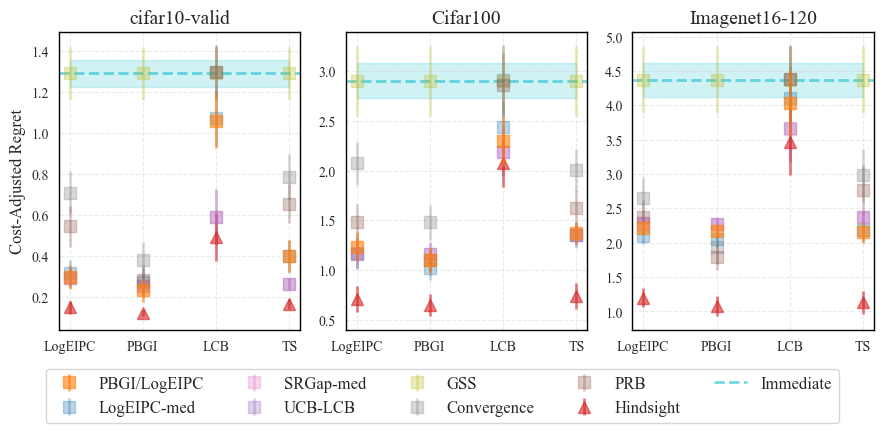

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from math import ceil

# Set style
sns.set_style('whitegrid', {
    'grid.linestyle': '--',
    'grid.alpha': 0.4
})

plt.style.use('seaborn-v0_8-bright')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    # 'xtick.rotation': 45,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.autolayout': False,  # we’ll call tight_layout() explicitly
})


def style_spines(ax, color='black', linewidth=1):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(color)
        spine.set_linewidth(linewidth)

# Config
dataset_names = ['cifar10-valid', 'cifar100', 'ImageNet16-120']
lam = 1e-6
lam_str = '1e-6'
acq_order = ['LogEIPC', 'PBGI', 'LCB', 'TS']
init = 0
n_cols = len(acq_order)

# Set up plot
fig, axes = plt.subplots(1, len(dataset_names), figsize=(3 * len(dataset_names), 4 * 1), sharey=False)

for col, d in enumerate(dataset_names):
    ax = axes[col]
    best_acc = best_acc_per_dataset[d]
    best_error = 100. - best_acc

    # Collect Immediate values across all acquisition functions
    immediate_vals = []
    for j, acq in enumerate(acq_order):
        fixed_acq = f"PBGI({lam_str})" if acq == 'PBGI' else acq
        
        # Find Immediate rule for this acquisition function
        immediate_rule = None
        for rule in stopping_rules:
            if rule['acq_key'] == f"PBGI({lam_str})" and rule['stp_key'] == 'Immediate':
                immediate_rule = rule
                break
        
        if immediate_rule:
            stop_vals = []
            num_seeds = len(metrics_per_acq[d][fixed_acq]["estimated cumulative cost"])
            for seed in range(num_seeds):
                errs = metrics_per_acq[d][fixed_acq]["final test error"][seed][:201]
                costs = metrics_per_acq[d][fixed_acq]["estimated cumulative cost"][seed][:201]
                # Immediate stops at iteration 0
                stop_idx = 0
                stop_vals.append((errs[stop_idx] - best_error) + lam * costs[stop_idx])
            immediate_vals.extend(stop_vals)

    for j, acq in enumerate(acq_order):
        fixed_acq = f"PBGI({lam_str})" if acq == 'PBGI' else acq

        for rule in stopping_rules:
            if rule['acq_key'] != f"PBGI({lam_str})":
                continue
            
            # Skip Immediate rule here - we'll plot it separately
            if rule['stp_key'] == 'Immediate':
                continue

            stop_vals = []
            stop_iters = []
            non_stopping_count = 0  # <-- Track non-stopping seeds
            num_seeds = len(metrics_per_acq[d][fixed_acq]["estimated cumulative cost"])
            for seed in range(num_seeds):
                errs = metrics_per_acq[d][fixed_acq]["final test error"][seed][:201]
                costs = metrics_per_acq[d][fixed_acq]["estimated cumulative cost"][seed][:201]
                if rule['is_hindsight']:
                    regs = np.array(errs) - best_error + lam * np.array(costs)
                    idx = np.argmin(regs)
                else:
                    idx = next((k for k in range(init, len(errs)) if rule['condition_fn'](k, seed, d)), len(errs) - 1)
                    if idx == len(errs) - 1:
                        non_stopping_count += 1  # <-- Count seeds that never stopped early
                stop_vals.append((errs[idx] - best_error) + lam * costs[idx])

            mean_val = np.mean(stop_vals)
            err_val = np.std(stop_vals) / np.sqrt(len(stop_vals))

            alpha = 0.6 if (rule['stp_key'] == 'PBGI' or rule['is_hindsight']) else 0.3
            zorder = 3 if rule['stp_key'] == 'PBGI' else 2
            marker = "^" if rule['is_hindsight'] else 's' 
            ax.errorbar(j, mean_val, yerr=2 * err_val,
                        fmt=marker,
                        markersize=8,
                        linewidth=2,
                        color=rule['color'],
                        capsize=0,
                        alpha=alpha,
                        zorder=zorder,
                        label=rule['label'])
            
            # --- Output non-stopping stats ---
            # print(f"[{d}] Acquisition: {acq}, Rule: {rule['label']}, Non-stopping seeds: {non_stopping_count} / {num_seeds}")
    
    # Plot Immediate as horizontal line with shaded error bars
    if immediate_vals:
        immediate_mean = np.mean(immediate_vals)
        immediate_err = np.std(immediate_vals) / np.sqrt(len(immediate_vals))
        
        # Draw horizontal line across all acquisition functions
        ax.axhline(y=immediate_mean, xmin=0, xmax=1, 
                  color='tab:cyan', linestyle='--', linewidth=2, alpha=0.6, zorder=1)
        
        # Add shaded error region
        ax.fill_between([0, len(acq_order)-1], 
                       [immediate_mean - 2*immediate_err, immediate_mean - 2*immediate_err],
                       [immediate_mean + 2*immediate_err, immediate_mean + 2*immediate_err],
                       color='tab:cyan', alpha=0.2, zorder=0)
        
        # Add label only once
        if col == 0:  # Only add label for the first subplot
            ax.plot([], [], color='tab:cyan', linestyle='--', linewidth=2, 
                   alpha=0.6, label='Immediate')

    ax.set_xticks(range(n_cols))
    ax.set_xticklabels(acq_order)
    if (d == "cifar10-valid"):
        ax.set_title(d)
    else:
        ax.set_title(d.capitalize())
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_ylabel("Cost-Adjusted Regret" if col == 0 else "")
    style_spines(ax)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
legend_hls = dict(zip(labels, handles))

# Move Immediate to the end if it exists
if 'Immediate' in legend_hls:
    immediate_handle = legend_hls.pop('Immediate')
    legend_hls['Immediate'] = immediate_handle

fig.legend(legend_hls.values(), legend_hls.keys(),
           loc='lower center',
           bbox_to_anchor=(0.5, -0.15),
           ncol=ceil(len(legend_hls) / 2),
           fontsize=12)

# fig.suptitle(f"Cost-Adjusted Regret (λ = {str(lam)})", fontsize=20)
plt.tight_layout(rect=[0, 0.0, 1, 0.95])
plt.savefig(f'../plots/BarPlot_NATS_1e-6.pdf', bbox_inches='tight')
plt.show()

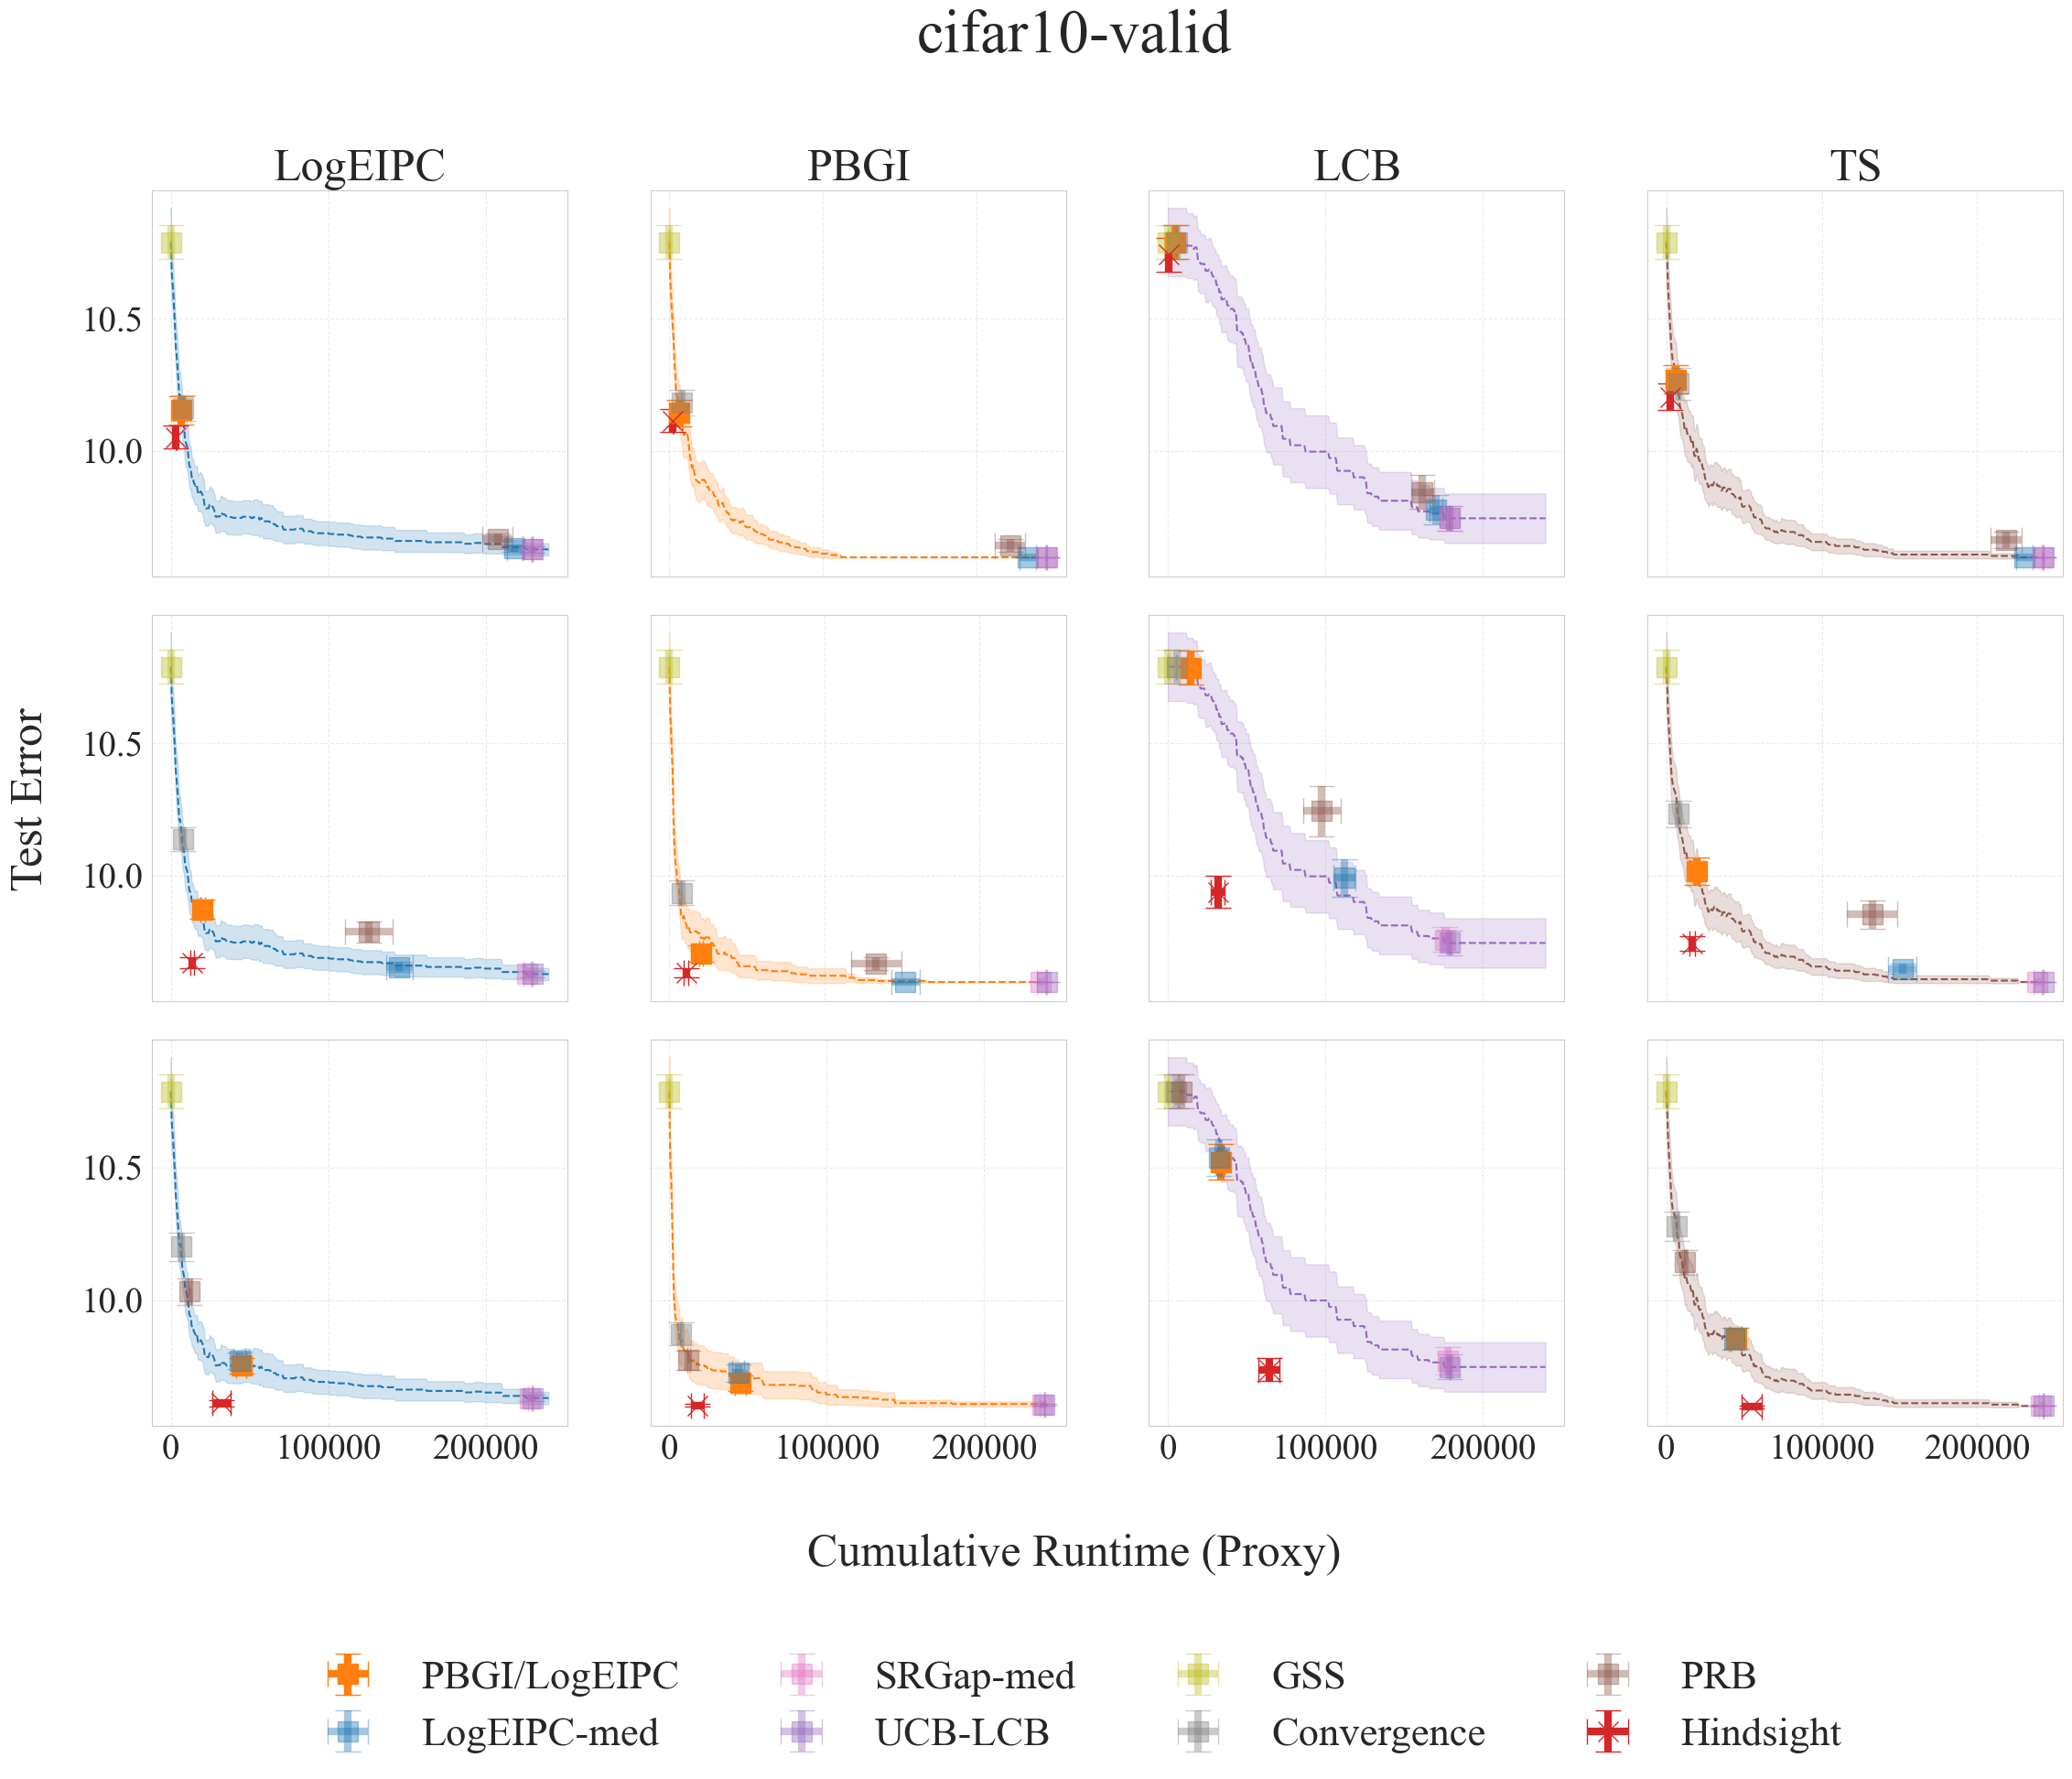

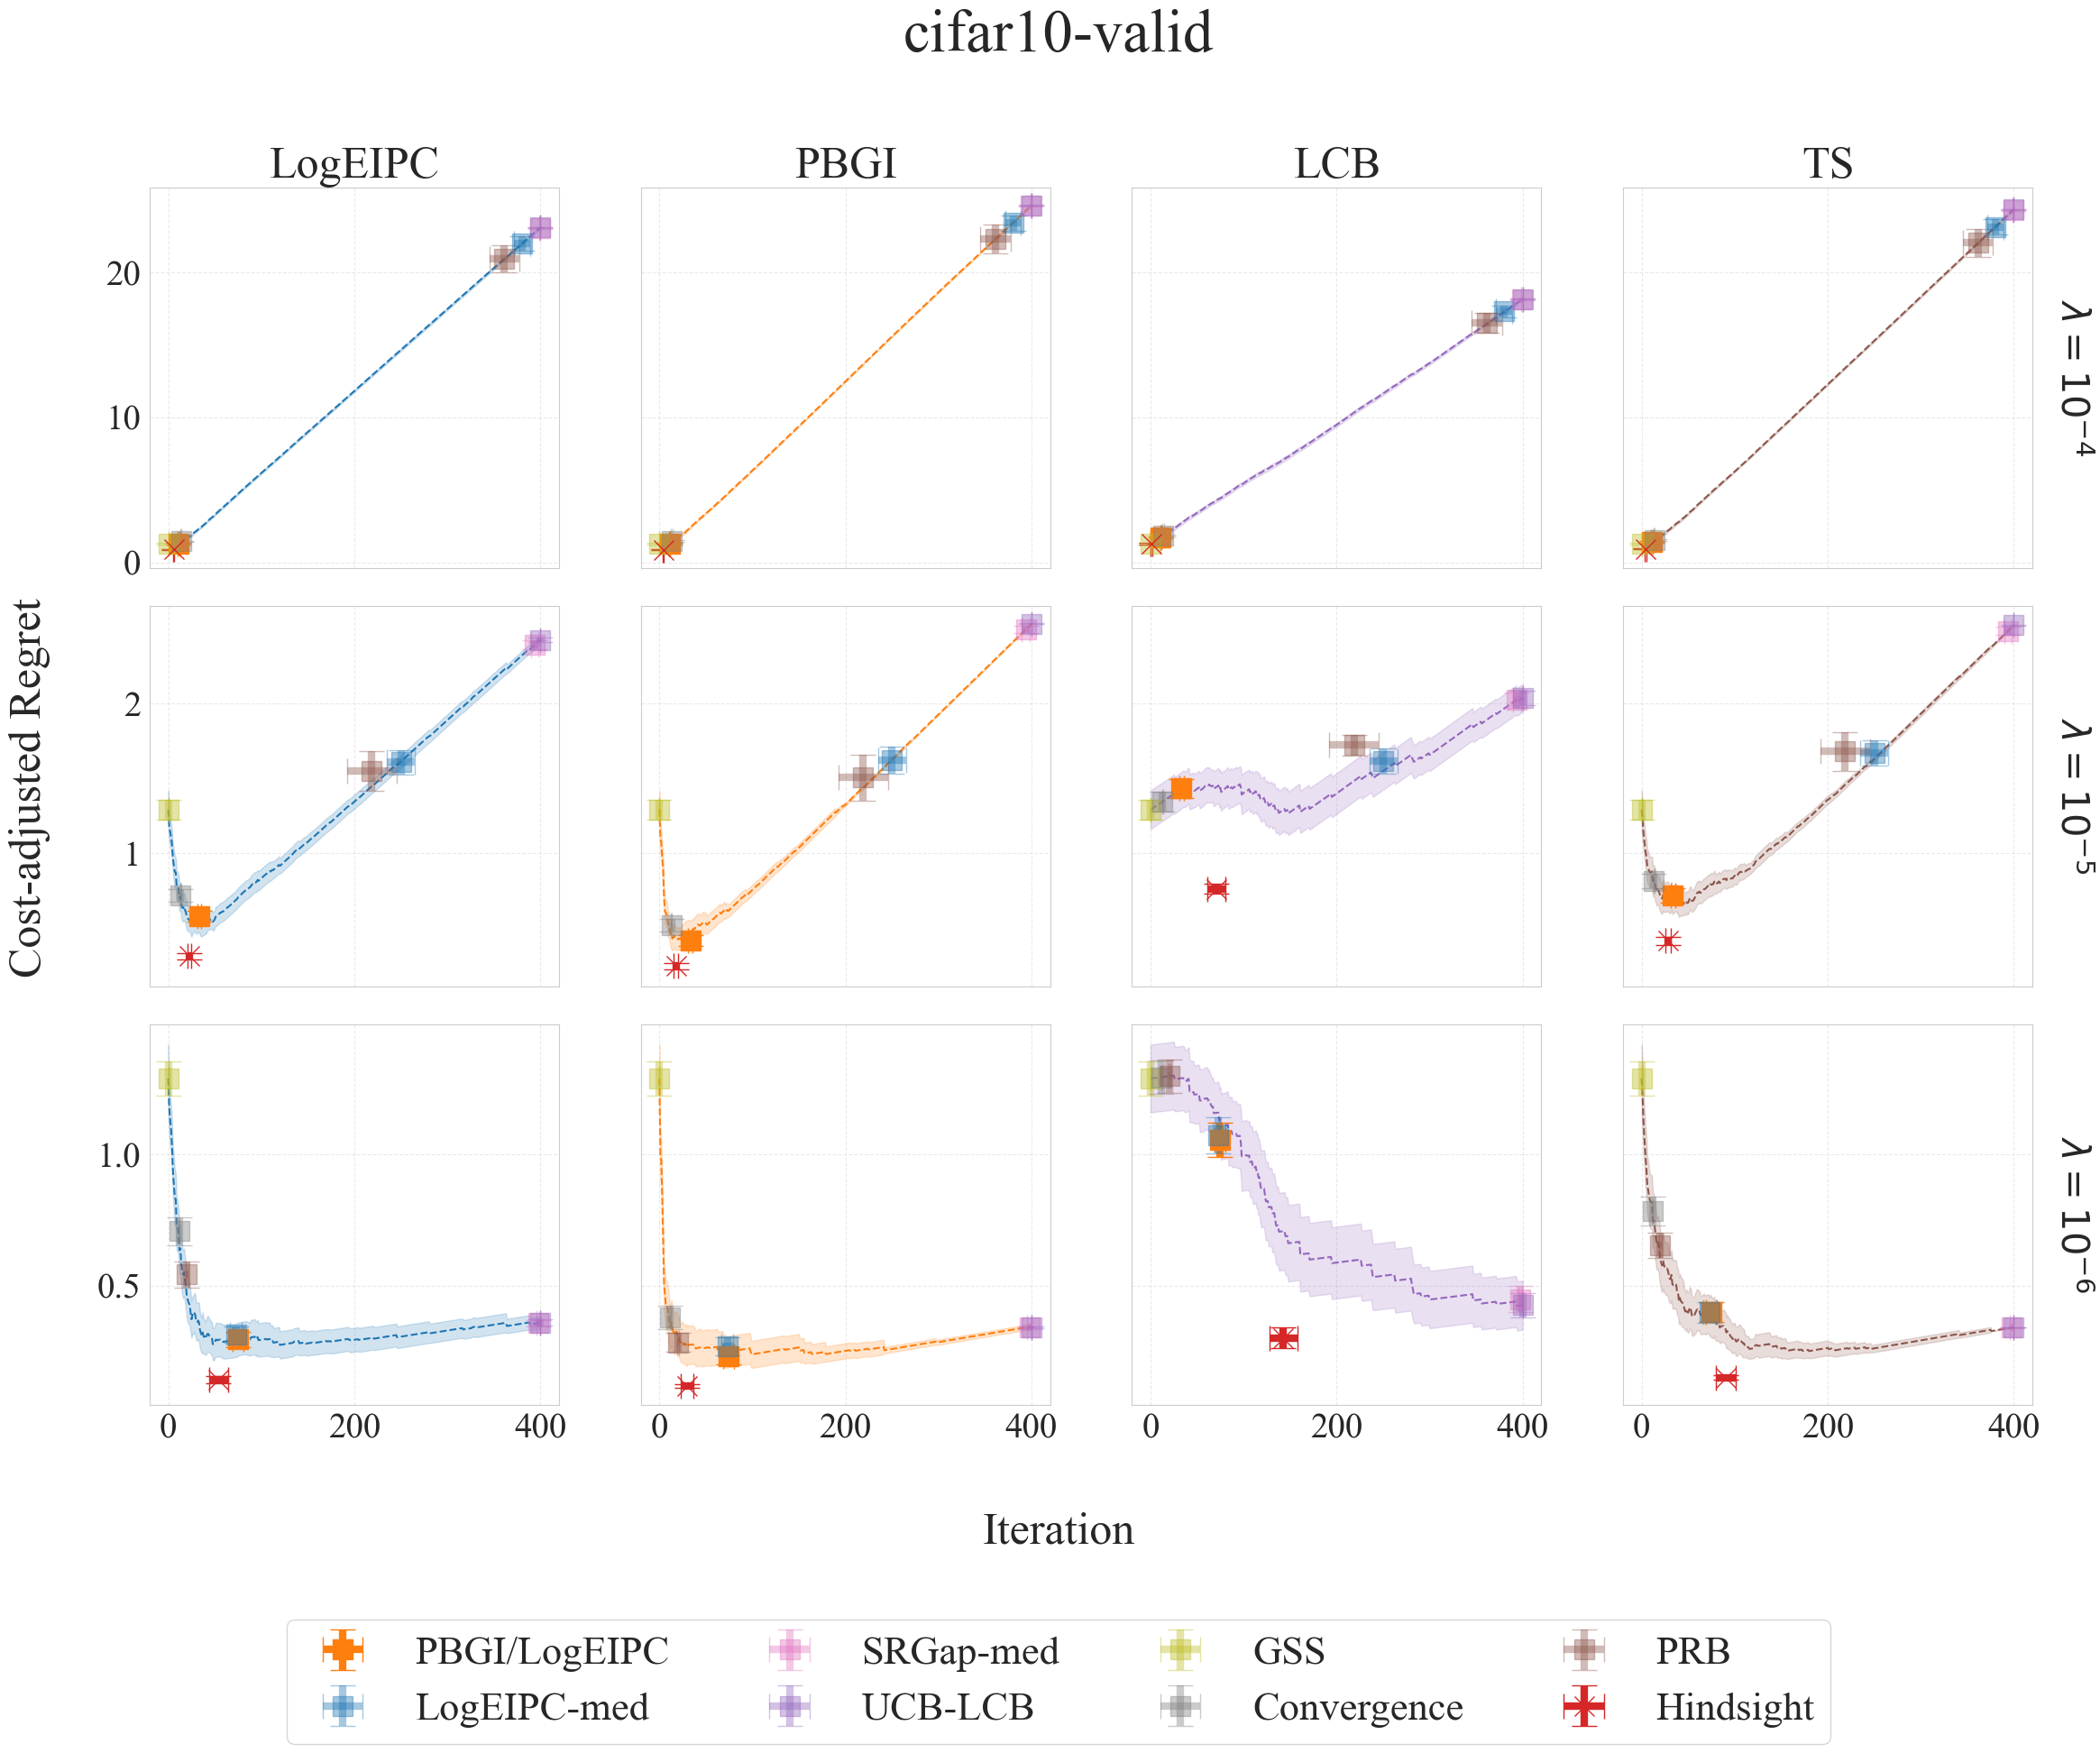

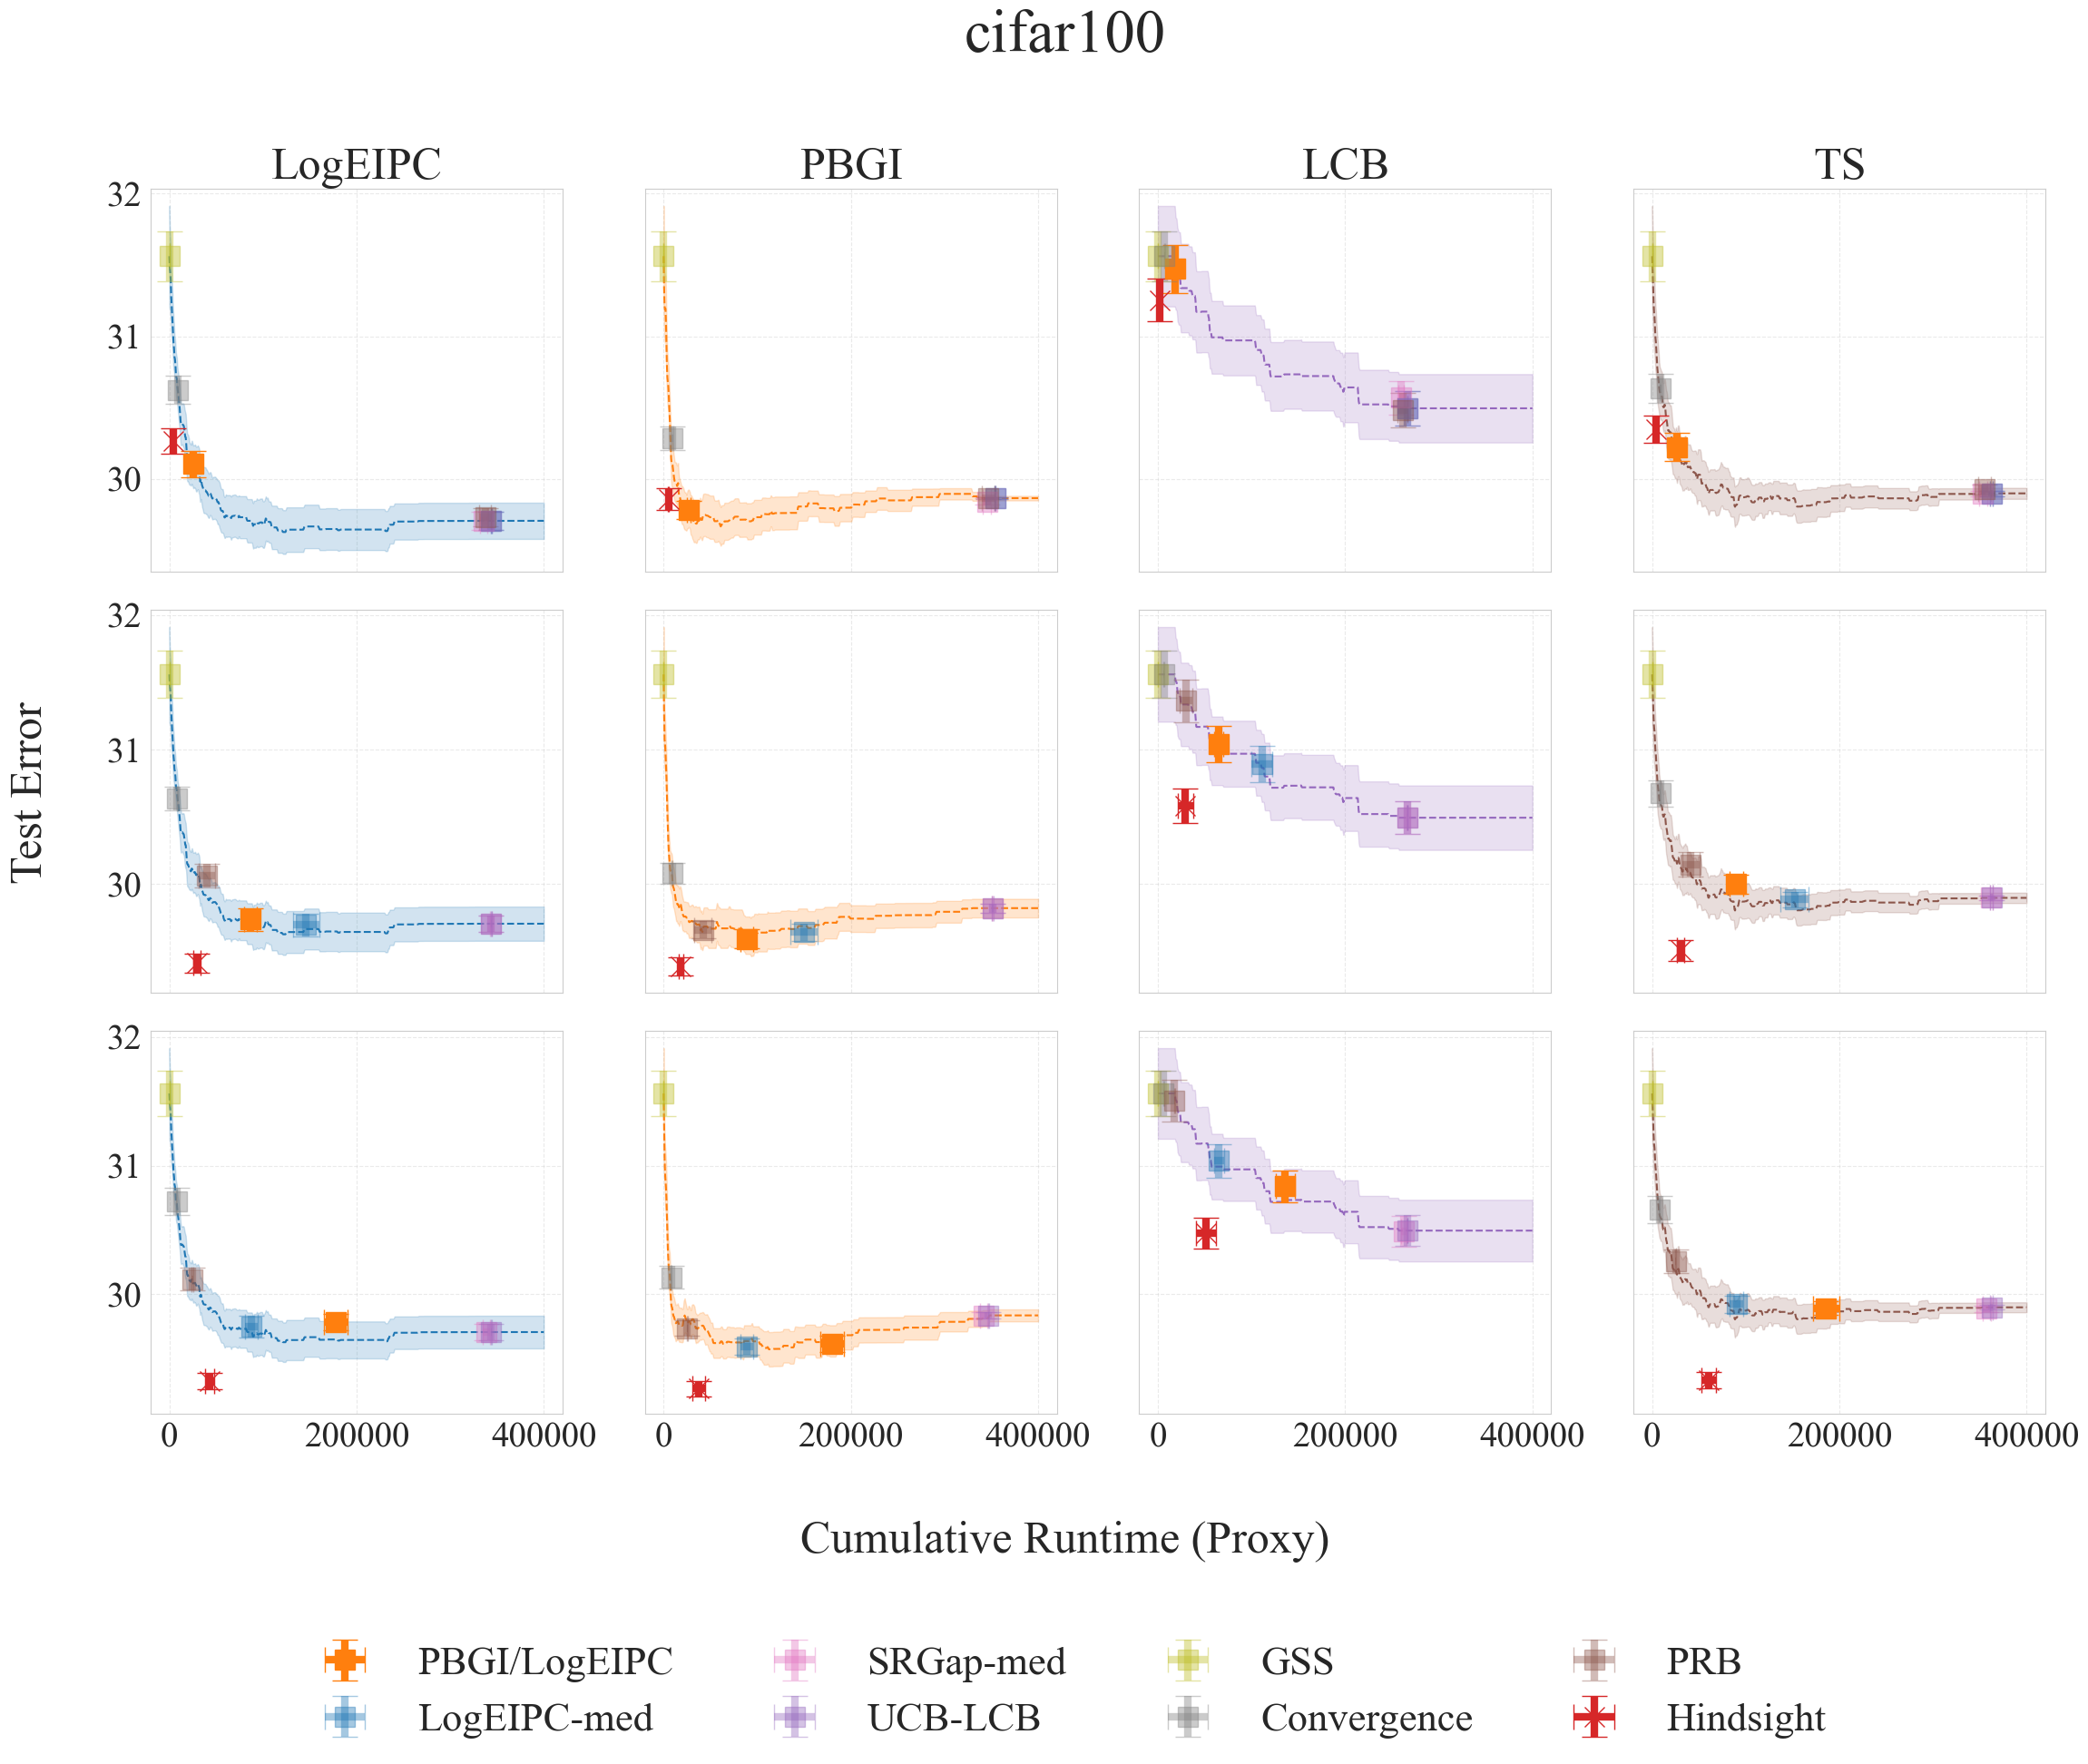

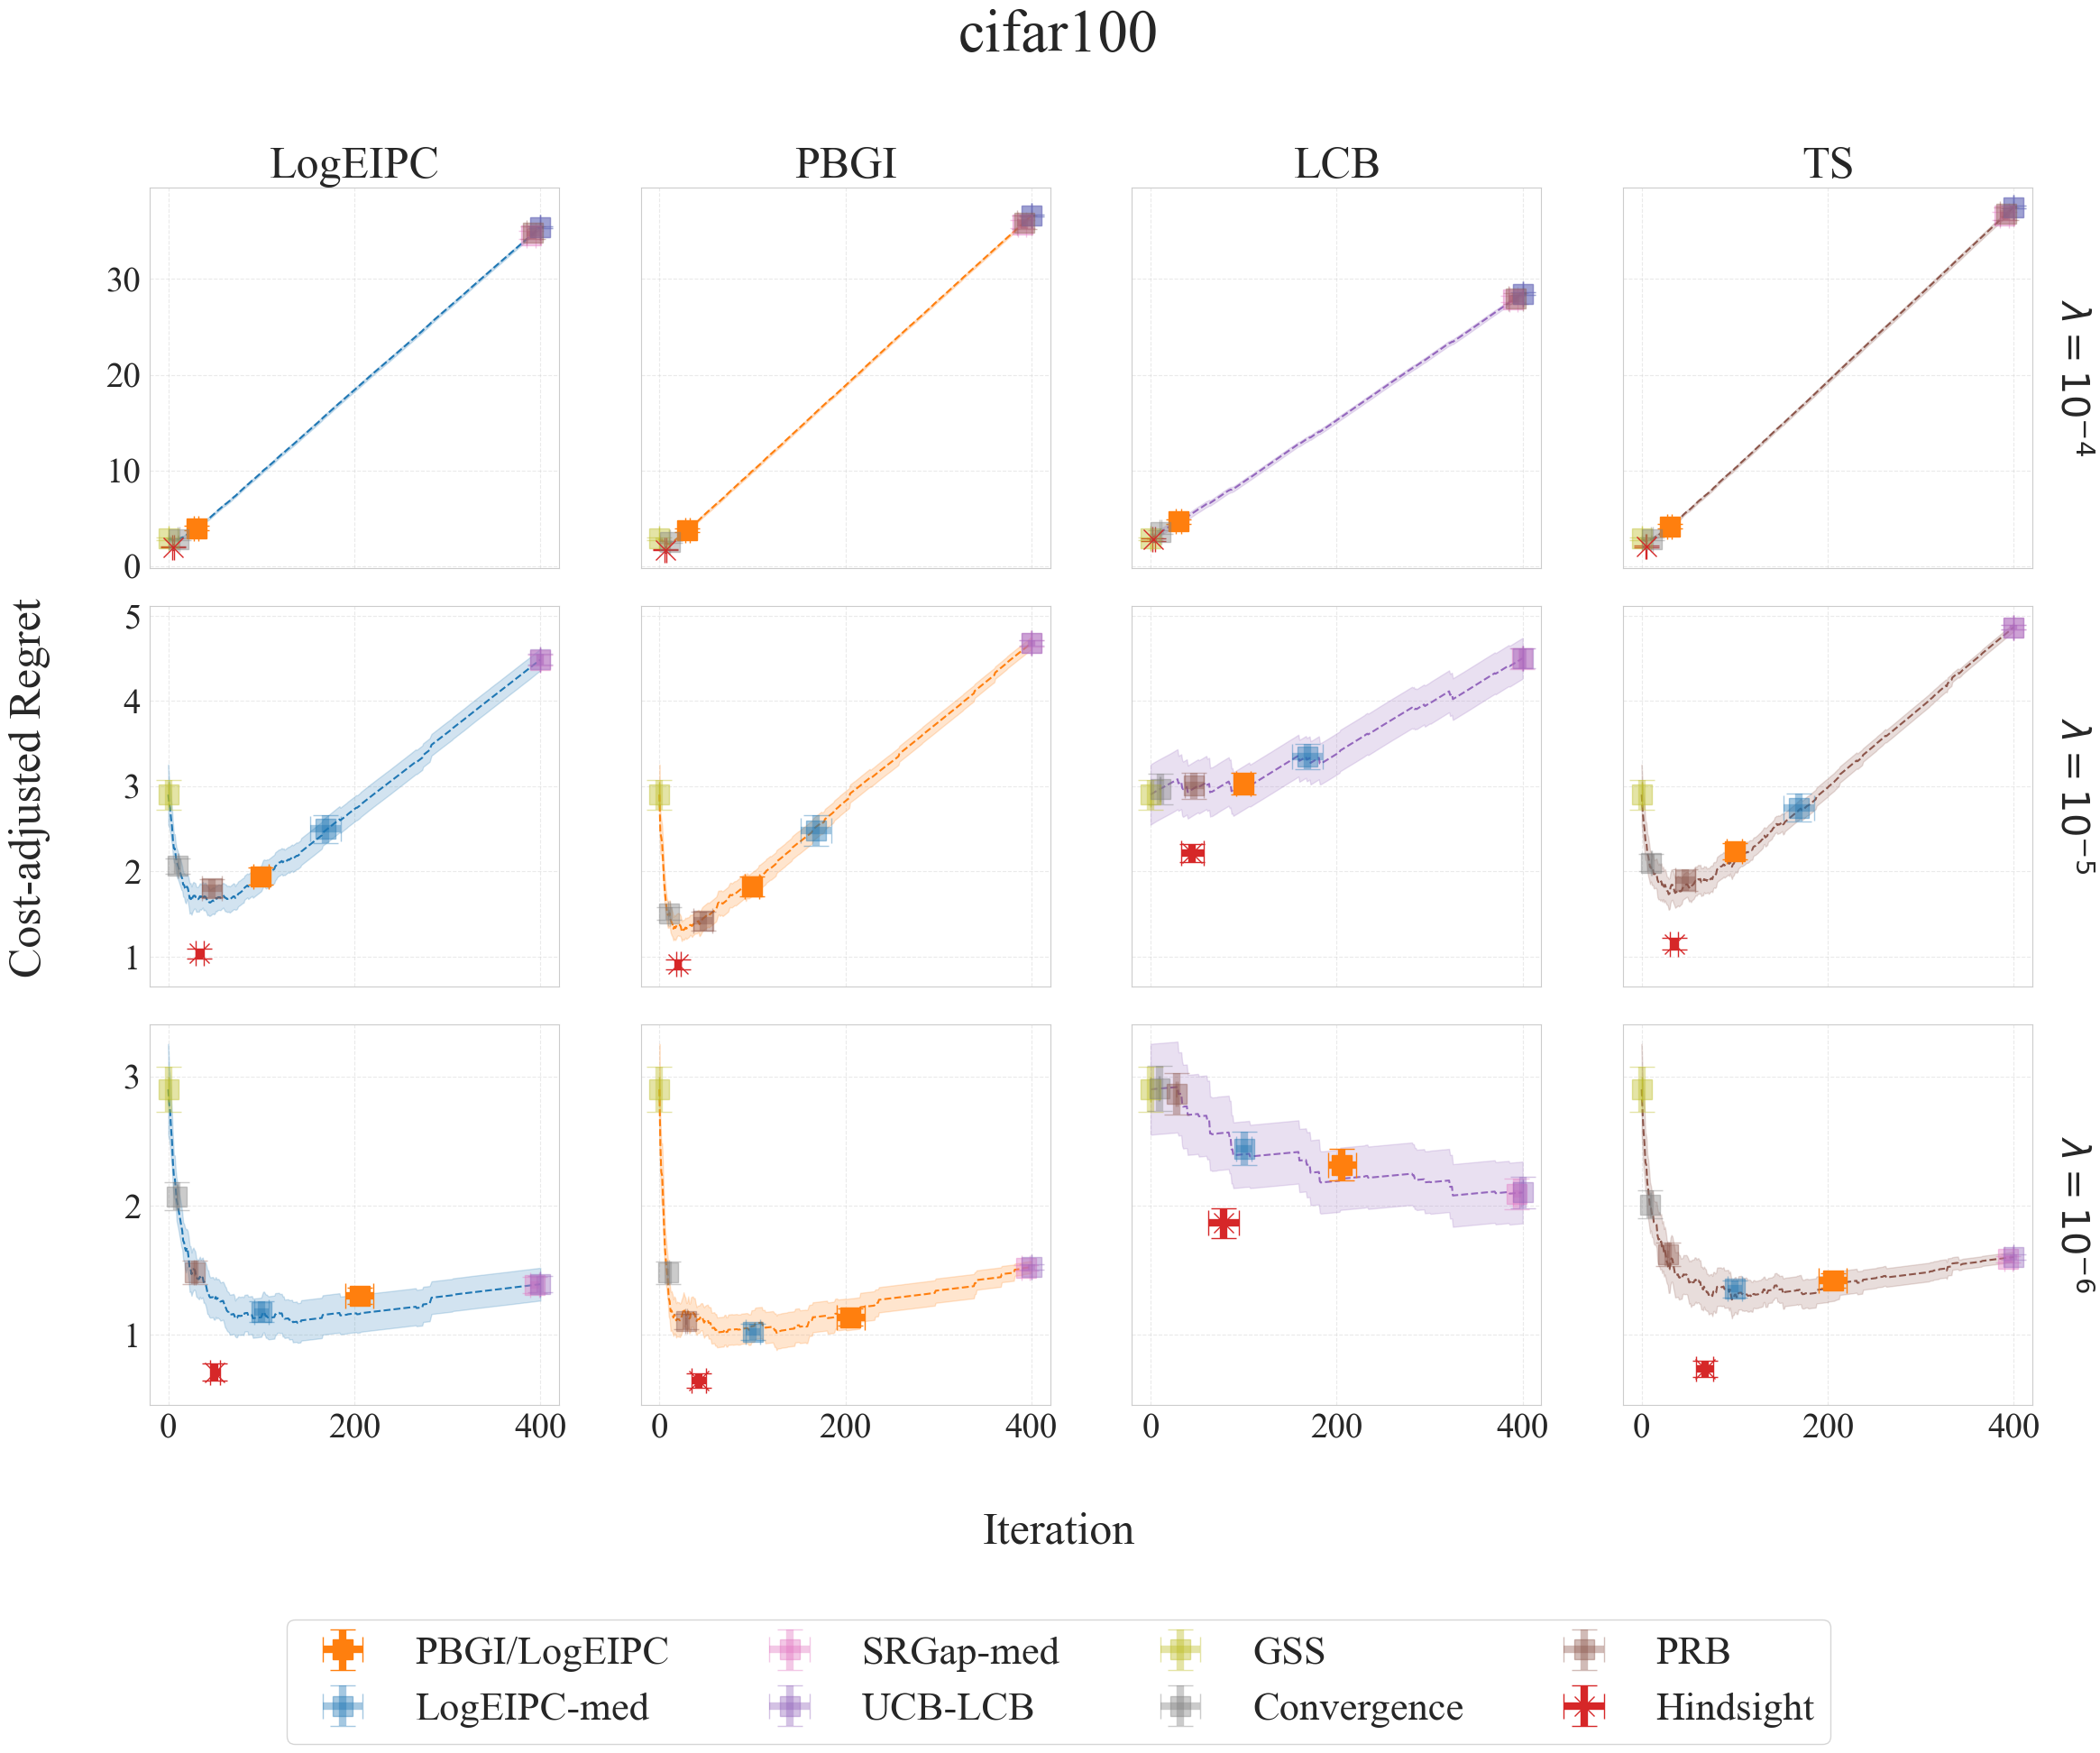

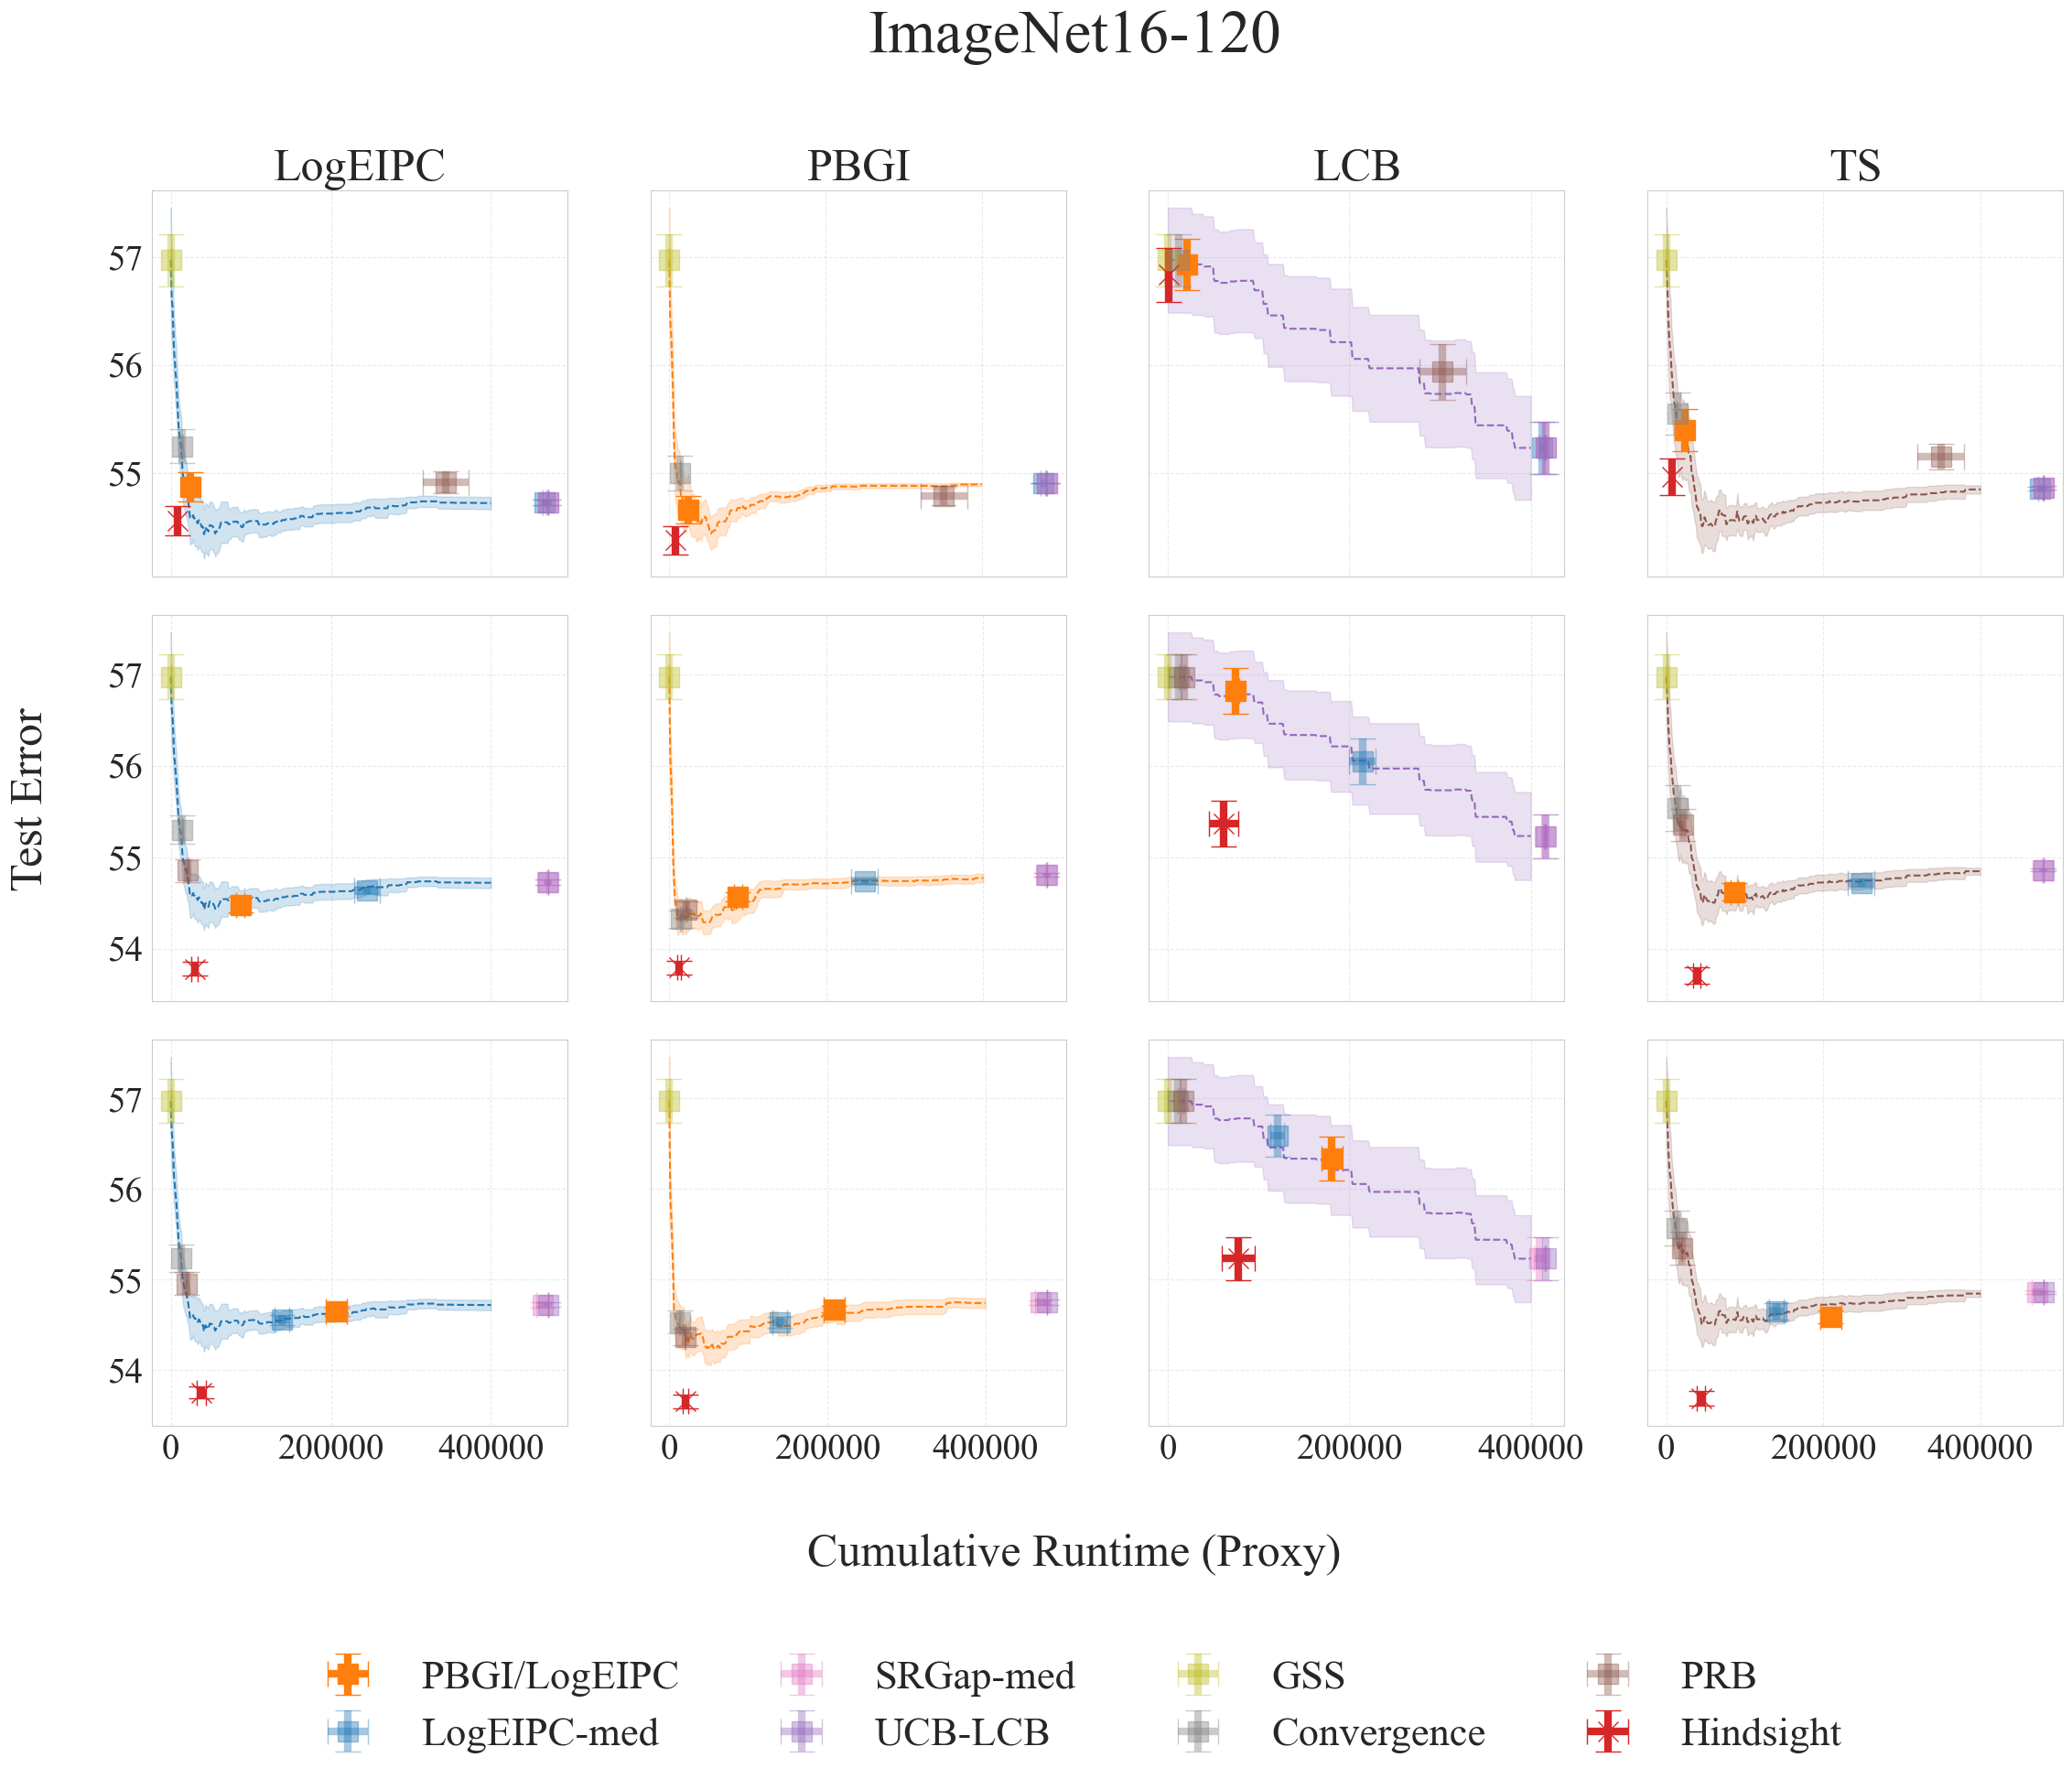

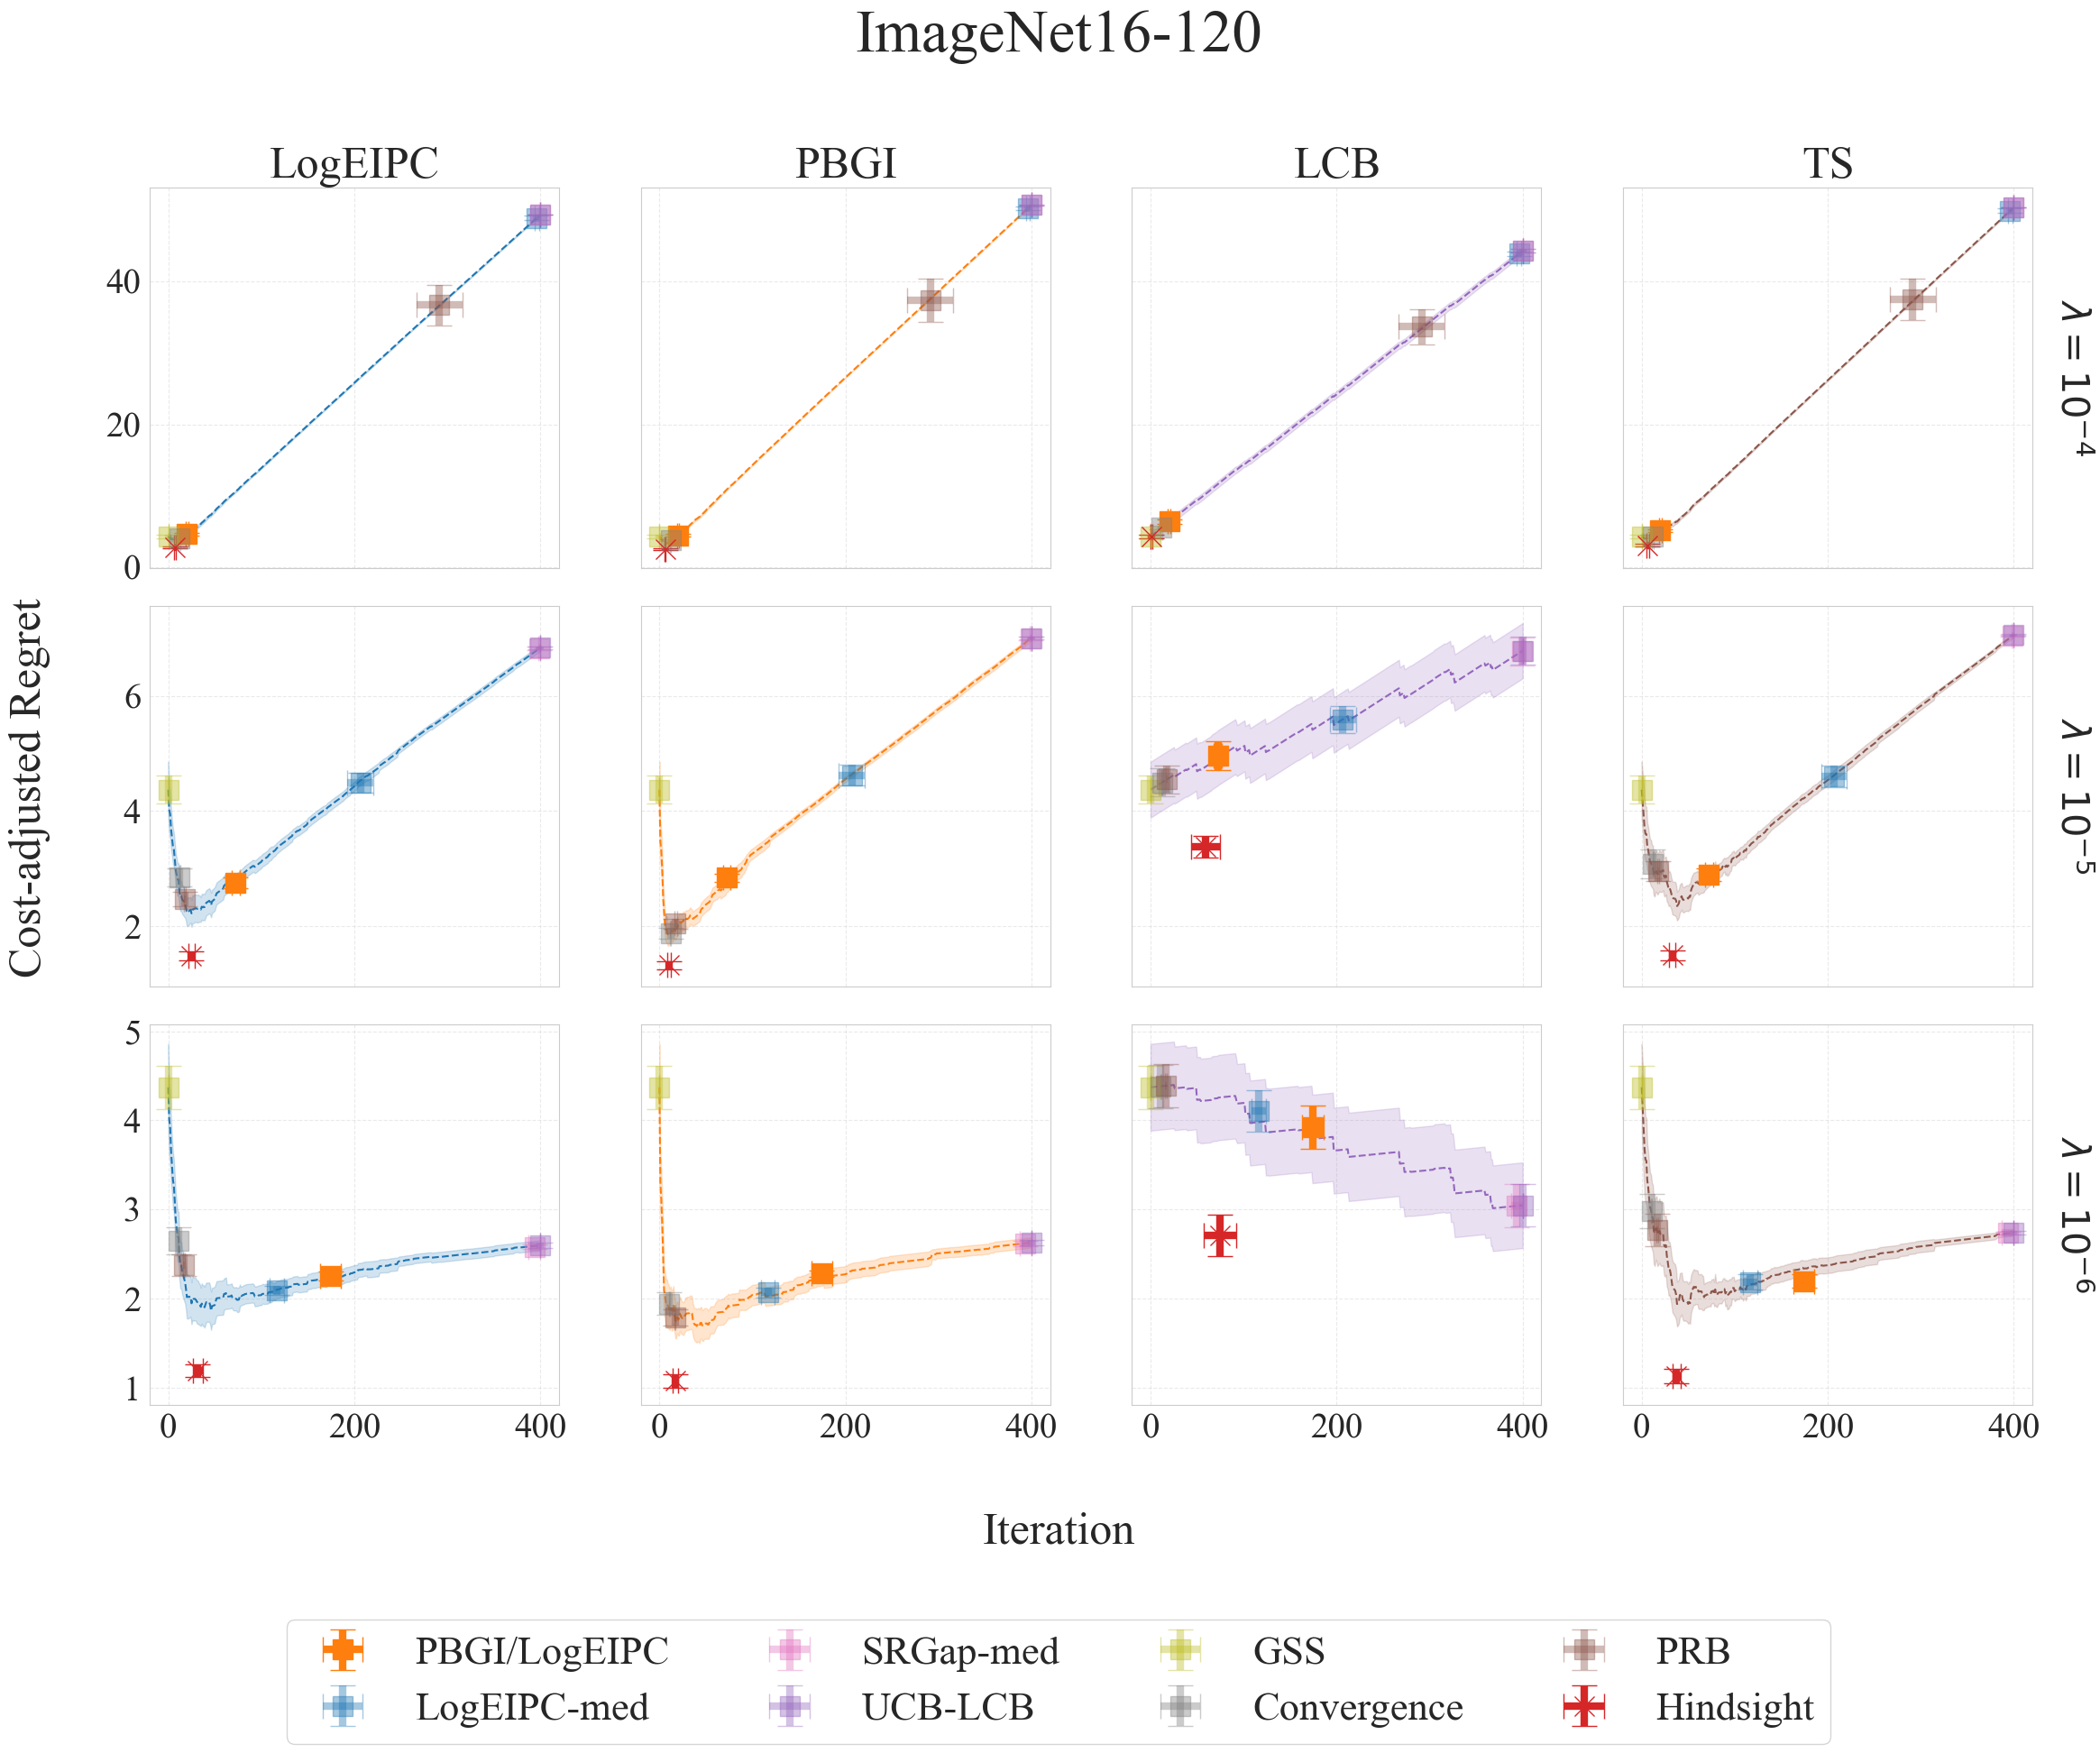

In [9]:
# === Plotting ===
for d in dataset_names:
    best_acc   = best_acc_per_dataset[d]
    best_error = 100. - best_acc

    # === 1) Test error vs estimated cumulative cost ===
    fig, axes = plt.subplots(3, 4, figsize=(24, 18), sharey="row")
    fig.suptitle(f"{d}", fontsize=48)
    for i, lam in enumerate(lambdas):
        lam_str = f"1e-{int(round(-np.log10(lam)))}"

        for j in range(4):
            acq = acq_order[j]
            fixed_acq = f"PBGI({lam_str})" if acq == 'PBGI' else acq
            ax = axes[i, j]

            # === Mean test error curve ===
            cost_grid = np.linspace(0, cost_limit_per_dataset[d], 801)
            curves = []
            for seed in range(len(metrics_per_acq[d][fixed_acq]["estimated cumulative cost"])):
                c = np.array(metrics_per_acq[d][fixed_acq]["estimated cumulative cost"][seed])
                e = np.array(metrics_per_acq[d][fixed_acq]["final test error"][seed])
                idx = np.argsort(c)
                curves.append(np.interp(cost_grid, c[idx], e[idx]))
            curves = np.vstack(curves)
            mean_c = curves.mean(axis=0)
            sem_c  = curves.std(axis=0) / np.sqrt(curves.shape[0])

            ax.plot(cost_grid, mean_c, linestyle='--', color=color_dict[fixed_acq])
            ax.fill_between(cost_grid, mean_c - 2 * sem_c, mean_c + 2 * sem_c, color=color_dict[fixed_acq], alpha=0.2)

            # === Stopping rule overlays ===
            for rule in stopping_rules:
                # Only use rules from the correct lambda
                if rule['acq_key'] != f"PBGI({lam_str})":
                    continue
                
                # Skip Immediate rule in iteration plots
                if rule['stp_key'] == 'Immediate':
                    continue

                stop_vals = []
                stop_costs = []
                for seed in range(curves.shape[0]):
                    errs = metrics_per_acq[d][fixed_acq]["final test error"][seed]
                    costs = metrics_per_acq[d][fixed_acq]["estimated cumulative cost"][seed]
                    if rule['is_hindsight']:
                        regs = np.array(errs) - best_error + lam * np.array(costs)
                        idx = np.argmin(regs)
                    else:
                        idx = next((k for k in range(init, len(errs)) if rule['condition_fn'](k, seed, d)), len(errs) - 1)
                    stop_vals.append(errs[idx])
                    stop_costs.append(costs[idx])

                mx = np.mean(stop_costs)
                my = np.mean(stop_vals)
                sx = np.std(stop_costs) / np.sqrt(len(stop_costs))
                sy = np.std(stop_vals) / np.sqrt(len(stop_vals))

                alpha = 1.0 if (rule['stp_key'] == 'PBGI' or rule['stp_key'] == 'Hindsight') else 0.4
                ax.errorbar(mx, my, xerr=sx, yerr=sy,
                            fmt=rule['marker'],
                            markersize=16,
                            linewidth=6,
                            color=rule['color'],
                            capsize=10,
                            alpha=alpha,
                            label=rule['label'])

            if i == 0:
                ax.set_title(acq, fontsize=36)  # only first row
            ax.tick_params(axis='both', which='major', labelsize=28)
            if i != 2:
                ax.set_xticklabels([])
                ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
            ax.grid(True, linestyle='--', alpha=0.4)

    fig.subplots_adjust(left=0.08, right=0.95, bottom=0.12, top=0.87, hspace=0.1)

    fig.text(0.5, 0.035, 'Cumulative Runtime (Proxy)', ha='center', fontsize=36)
    fig.text(0.015, 0.5, 'Test Error', va='center', rotation='vertical', fontsize=36)

    # Two-row legend
    from math import ceil
    handles, labels = axes[0, 0].get_legend_handles_labels()
    half = ceil(len(handles) / 2)
    fig.legend(
        handles, labels,
        loc='upper center',
        bbox_to_anchor=(0.5, 0.0),
        ncol=half,
        fontsize=32,
        frameon=False
    )

    # === 2) Regret + λ·cost vs iteration ===
    fig, axes = plt.subplots(3, 4, figsize=(24, 18), sharey='row')
    fig.suptitle(f"{d}", fontsize=48)
    for i, lam in enumerate(lambdas):
        lam_str = f"1e-{int(round(-np.log10(lam)))}"

        for j in range(4):
            acq = acq_order[j]
            fixed_acq = f"PBGI({lam_str})" if acq == 'PBGI' else acq
            ax = axes[i, j]

            regs_all = []
            for seed in range(len(metrics_per_acq[d][fixed_acq]["estimated cumulative cost"])):
                errs = np.array(metrics_per_acq[d][fixed_acq]["final test error"][seed])
                costs = np.array(metrics_per_acq[d][fixed_acq]["estimated cumulative cost"][seed])
                regs_all.append((errs - best_error) + lam * costs)
            regs_all = np.vstack(regs_all)
            mean_r = regs_all.mean(axis=0)
            sem_r  = regs_all.std(axis=0) / np.sqrt(regs_all.shape[0])
            iters  = np.arange(mean_r.shape[0])

            ax.plot(iters, mean_r, linestyle='--', color=color_dict[fixed_acq])
            ax.fill_between(iters, mean_r - 2 * sem_r, mean_r + 2 * sem_r, color=color_dict[fixed_acq], alpha=0.2)

            # === Stopping rule overlays ===
            for rule in stopping_rules:
                # Only use rules from the correct lambda
                if rule['acq_key'] != f"PBGI({lam_str})":
                    continue
                
                # Skip Immediate rule in iteration plots
                if rule['stp_key'] == 'Immediate':
                    continue

                stop_vals = []
                stop_iters = []
                for seed in range(regs_all.shape[0]):
                    seq = regs_all[seed]
                    if rule['is_hindsight']:
                        idx = np.argmin(seq)
                    else:
                        idx = next((k for k in range(init, len(seq)) if rule['condition_fn'](k, seed, d)), len(seq) - 1)
                    stop_vals.append(seq[idx])
                    stop_iters.append(idx)

                mx = np.mean(stop_iters)
                my = np.mean(stop_vals)
                sx = np.std(stop_iters) / np.sqrt(len(stop_iters))
                sy = np.std(stop_vals) / np.sqrt(len(stop_vals))

                alpha = 1.0 if (rule['stp_key'] == 'PBGI' or rule['stp_key'] == 'Hindsight') else 0.4
                ax.errorbar(mx, my, xerr=sx, yerr=sy,
                            fmt=rule['marker'],
                            markersize=16,
                            linewidth=6,
                            color=rule['color'],
                            capsize=10,
                            alpha=alpha,
                            label=rule['label'])

            if i == 0:
                ax.set_title(acq, fontsize=36)
            ax.tick_params(axis='both', which='major', labelsize=28)
            if i != 2:
                ax.set_xticklabels([])
                ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
            ax.grid(True, linestyle='--', alpha=0.4)

    # Rotated lambda labels on the right
    lambda_labels = [r'$\lambda=10^{-4}$', r'$\lambda=10^{-5}$', r'$\lambda=10^{-6}$']
    for i, label in enumerate(lambda_labels):
        ax = axes[i, -1]
        ax.text(1.05, 0.5, label, transform=ax.transAxes, va='center', ha='left', fontsize=30, rotation=270)
    
    fig.subplots_adjust(left=0.08, right=0.95, bottom=0.12, top=0.87, hspace=0.1)

    fig.text(0.5, 0.035, 'Iteration', ha='center', fontsize=36)
    fig.text(0.015, 0.5, 'Cost-adjusted Regret', va='center', rotation='vertical', fontsize=36)

    # Two-row legend
    from math import ceil
    handles, labels = axes[0, 0].get_legend_handles_labels()
    half = ceil(len(handles) / 2)
    fig.legend(
        handles, labels,
        loc='upper center',
        bbox_to_anchor=(0.5, 0.0),
        ncol=half,
        fontsize=32
    )
    plt.savefig(f'../plots/{d}.pdf', bbox_inches='tight')
    plt.show()